# Outlier EDA for daily sales quantities

This notebook examines daily product-store observations after tail and minimum-demand filtering for the **FCM** and **Pseudo** sourcing groups. It separates statistical outlier detection from the eventual cleaning decision. Candidates are detected separately within every (`ARTIKEL_ID`, `MARKT_ID`) series.

The cleaning decision is deliberately conservative:

- **Probable data error:** the exact product-store-date key retained from manual EDA when it remains after upstream filtering are removed. The statistical rules explain why they were inspected, but are not generalized into an automatic deletion rule.
- **Aktion plausible:** `AKTION_KENNZEICHEN = 1` on the candidate date.
- **Rabatt-related candidate:** `RABATT = 1` on the candidate date. Rabatt is recorded ex post and is not known at forecast time. Because these markdowns are commonly used to clear perishable stock close to spoilage, an extreme discounted sale reflects a clearance intervention rather than the baseline-demand target used here. Such rows are capped at the series-specific 95th percentile of positive demand; ordinary Rabatt observations at or below that percentile are unchanged.
- **Cross-store plausible:** the same product is flagged in at least three stores within ±3 days.
- **Cross-product plausible:** at least three products in the same merchandise group and store are flagged within ±3 days.
- **Seasonally/calendar plausible:** either a calendar month contains candidates in at least two years and its candidate rate is at least twice the series' full-year rate, or the candidate lies in a defined pre-/post-holiday demand window. Recurrence across years remains visible as stronger supporting evidence. These observations are retained and shown as demand structure.
- **Unexplained:** all remaining candidates. They are marked for review, not removed.

The conservative statistical candidate fence uses `Q3 + 5 × IQR`, while the independent Rabatt cap uses the positive-demand 95th percentile. Zero-demand rows are excluded from Q1, the median, and Q3 because intermittent series would otherwise frequently have an IQR of zero. All analysed and plotted demand values come from `ABVERKAUFTE_MENGE_KG` and are therefore labelled in kg; `VERKAUFSEINHEIT` remains metadata only. Calendar evidence uses Niedersachsen public holidays: seven days before/after a holiday, with a 14-day pre-Christmas window. The primary plausibility labels are descriptive; the independent cleaning action determines removal, capping, or retention.

This treatment is appropriate only because the modeling target is **baseline demand without unplanned clearance markdowns**. If the operational target were realized sales under a future markdown policy, Rabatt effects would belong in the target and should instead be forecast or supplied as planned future covariates.

In [37]:
from pathlib import Path
from io import BytesIO
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import holidays
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display, Image

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 90)

DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
GROUP_ORDER = ["FCM", "Pseudo"]
GROUP_COLORS = {"FCM": "#c4513b", "Pseudo": "#d7a84b"}
CLASS_ORDER = [
    "Probable data error", "Seasonally plausible",
    "Cross-store plausible", "Cross-product plausible",
    "Aktion plausible", "Rabatt-related", "Unexplained",
]
CLASS_COLORS = {
    "Probable data error": "#d62728",
    "Aktion plausible": "#e377c2",
    "Rabatt-related": "#9467bd",
    "Cross-store plausible": "#1f77b4",
    "Cross-product plausible": "#17becf",
    "Seasonally plausible": "#2ca02c",
    "Unexplained": "#ff9f1c",
}
IQR_K = 5.0
RABATT_CAP_QUANTILE = 0.95
MIN_SEASONAL_CANDIDATES_IN_MONTH = 3
MIN_SEASONAL_RATE_LIFT = 2.0
PRE_HOLIDAY_WINDOW_DAYS = 7
CHRISTMAS_PRE_HOLIDAY_WINDOW_DAYS = 14
POST_HOLIDAY_WINDOW_DAYS = 7
CROSS_SERIES_WINDOW_DAYS = 3
MIN_CROSS_STORES = 3
MIN_RELATED_PRODUCTS = 3
KNOWN_ERROR_ROWS = pd.DataFrame([
    {"ARTIKEL_ID": 328555, "MARKT_ID": 1100011, "period": "2023-10-09",
     "known_error_reason": "Manual EDA: isolated implausible daily quantity (100.085 kg versus 1.042 kg second-largest)"},
])
KNOWN_ERROR_ROWS["period"] = pd.to_datetime(KNOWN_ERROR_ROWS["period"])

PROJECT_ROOT = next(
    (p.resolve() for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing src/.")

DATA_DIR = PROJECT_ROOT / "data" / "interim" / "transactions_dst_daily_no_outliers_no_stale"
PARQUET_FILES = sorted(DATA_DIR.glob("*.parquet"))
if not PARQUET_FILES:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

con = duckdb.connect()
con.execute("PRAGMA threads=8")

def display_figure(fig, dpi=120):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

print(f"Reading {len(PARQUET_FILES)} yearly files from {DATA_DIR}")

Reading 4 yearly files from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_dst_daily_no_outliers_no_stale


## Population and sourcing groups

The source-group mapping includes **FCM**, which is internal production delivered ready to sell, and **Pseudo**, which is raw material processed in-store into final sales articles. FCM has precedence in the mapping, and Pseudo requires `is_pseudo = True` and `is_fcm = False`. The audit stops on overlapping/null flags, duplicate product-store dates, or a source group that changes within a series.

In [38]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW daily_rows AS
SELECT
    ARTIKEL_ID,
    MARKT_ID,
    CAST(DATE AS DATE) AS period,
    CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand,
    ARTIKEL_BEZ AS product_name,
    VERKAUFSEINHEIT AS sales_unit,
    WGR_ID,
    MANDANT_ID,
    CAST(COALESCE(AKTION_KENNZEICHEN, 0) AS INTEGER) AS action_flag,
    CAST(COALESCE(RABATT, 0) AS INTEGER) AS discount_flag,
    is_fcm,
    is_pseudo,
    CASE
        WHEN is_fcm THEN 'FCM'
        WHEN is_pseudo THEN 'Pseudo'
    END AS source_group
FROM read_parquet('{DATA_GLOB}')
WHERE is_active AND (is_fcm OR is_pseudo)
""")

population_audit = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
    MIN(period) AS first_date,
    MAX(period) AS last_date,
    COUNT_IF(is_fcm IS NULL OR is_pseudo IS NULL) AS null_source_flags,
    COUNT_IF(is_fcm AND is_pseudo) AS overlapping_source_flags
FROM daily_rows
""").fetchdf()

duplicate_dates = con.execute("""
SELECT COUNT(*) FROM (
    SELECT ARTIKEL_ID, MARKT_ID, period
    FROM daily_rows
    GROUP BY ALL HAVING COUNT(*) > 1
)
""").fetchone()[0]
changing_groups = con.execute("""
SELECT COUNT(*) FROM (
    SELECT ARTIKEL_ID, MARKT_ID
    FROM daily_rows
    GROUP BY ALL HAVING COUNT(DISTINCT source_group) > 1
)
""").fetchone()[0]
population_audit["duplicate_series_dates"] = duplicate_dates
population_audit["changing_source_groups"] = changing_groups
display(population_audit)

failure_columns = [
    "null_source_flags", "overlapping_source_flags",
    "duplicate_series_dates", "changing_source_groups",
]
if population_audit[failure_columns].sum(axis=1).iloc[0]:
    raise RuntimeError("Population/source-group audit failed.")

first_year = pd.Timestamp(population_audit.loc[0, "first_date"]).year
last_year = pd.Timestamp(population_audit.loc[0, "last_date"]).year
ni_holidays = holidays.country_holidays(
    "DE", subdiv="NI", years=range(first_year, last_year + 1), language="de"
)
holiday_events = pd.DataFrame({
    "event_date": pd.to_datetime(list(ni_holidays.keys())),
    "holiday_name": list(ni_holidays.values()),
})
con.register("holiday_events_df", holiday_events)
con.execute("""
CREATE OR REPLACE TEMP TABLE holiday_events AS
SELECT CAST(event_date AS DATE) AS event_date, holiday_name
FROM holiday_events_df
""")
print(f"Calendar context: {len(holiday_events)} Niedersachsen public holidays.")

,rows,series,first_date,last_date,null_source_flags,overlapping_source_flags,duplicate_series_dates,changing_source_groups
0,16847794,22009,2023-07-22,2026-07-21,0.0,0.0,0,0


Calendar context: 40 Niedersachsen public holidays.


## Why the standard Tukey rule is not a deletion rule here

The conventional upper fence `Q3 + 1.5 × IQR` assumes that observations far beyond the middle 50% are unusual enough to inspect. It does **not** establish that they are erroneous. Daily product-store demand violates the conditions under which a mechanical interpretation would be useful: the series are intermittent, positive demand is strongly right-skewed, scale differs sharply by product, and genuine peaks arise from weekdays, holidays, promotions, cross-store events, and seasonality. Including zeros would make the issue worse because many intermittent series would have `Q1 = Q3 = 0`.

The sensitivity analysis below therefore computes fences from positive observations only and compares several multipliers. The standard `1.5 × IQR` rule flags hundreds of thousands of rows and most evaluable series. Even much larger multipliers still return valid demand peaks. The fence is therefore used to **generate review candidates**, never to infer an error by itself. Rabatt capping is evaluated separately at the series-specific positive-demand 95th percentile, as documented below.

,k,positive_rows,candidate_rows,candidate_series,evaluable_series,candidate_row_rate,candidate_series_rate
0,1.5,"6,429,736","463,345","21,468","22,009",7.21%,97.54%
1,3.0,"6,429,736","163,567","17,475","22,009",2.54%,79.40%
2,5.0,"6,429,736","48,580","10,405","22,009",0.76%,47.28%
3,10.0,"6,429,736","4,887","2,009","22,009",0.08%,9.13%


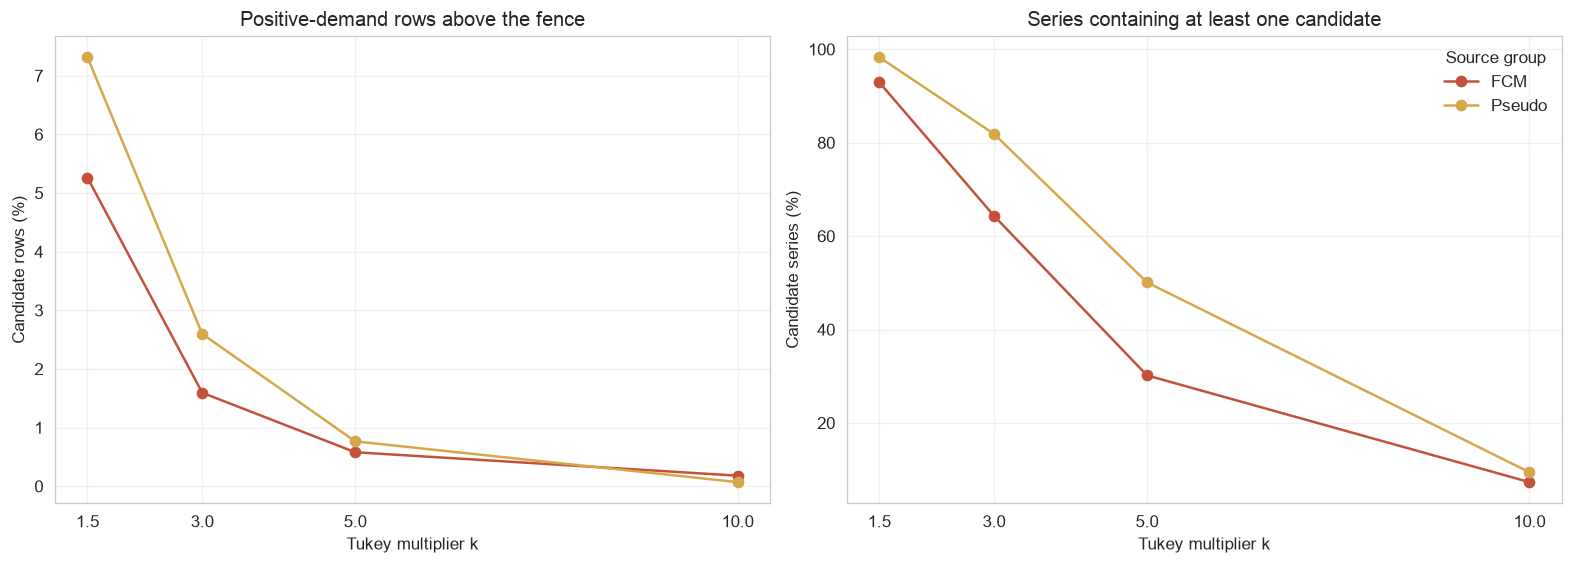

In [39]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE series_stats AS
SELECT
    source_group,
    ARTIKEL_ID,
    MARKT_ID,
    ANY_VALUE(product_name) AS product_name,
    ANY_VALUE(sales_unit) AS sales_unit,
    COUNT(*) AS observed_days,
    COUNT_IF(demand > 0) AS positive_days,
    QUANTILE_CONT(demand, 0.25) FILTER (WHERE demand > 0) AS q1,
    QUANTILE_CONT(demand, 0.50) FILTER (WHERE demand > 0) AS median_positive,
    QUANTILE_CONT(demand, 0.75) FILTER (WHERE demand > 0) AS q3,
    MAX(demand) AS maximum_demand
FROM daily_rows
GROUP BY source_group, ARTIKEL_ID, MARKT_ID
""")

tukey_sensitivity = con.execute(f"""
WITH multipliers(k) AS (VALUES (1.5), (3.0), ({IQR_K}), (10.0)),
evaluable AS (
    SELECT d.*, s.positive_days, s.q1, s.q3
    FROM daily_rows d
    JOIN series_stats s USING (source_group, ARTIKEL_ID, MARKT_ID)
    WHERE d.demand > 0
),
series_denominator AS (
    SELECT source_group, COUNT(*) AS evaluable_series
    FROM series_stats
    GROUP BY source_group
)
SELECT
    m.k, e.source_group, COUNT(*) AS positive_rows,
    COUNT_IF(e.demand > e.q3 + m.k * (e.q3 - e.q1)) AS candidate_rows,
    COUNT(DISTINCT (e.ARTIKEL_ID, e.MARKT_ID)) FILTER (
        WHERE e.demand > e.q3 + m.k * (e.q3 - e.q1)
    ) AS candidate_series,
    d.evaluable_series
FROM evaluable e
CROSS JOIN multipliers m
JOIN series_denominator d USING (source_group)
GROUP BY m.k, e.source_group, d.evaluable_series
ORDER BY m.k, e.source_group
""").fetchdf()
tukey_sensitivity["candidate_row_rate"] = (
    tukey_sensitivity["candidate_rows"] / tukey_sensitivity["positive_rows"]
)
tukey_sensitivity["candidate_series_rate"] = (
    tukey_sensitivity["candidate_series"] / tukey_sensitivity["evaluable_series"]
)

overall_sensitivity = tukey_sensitivity.groupby("k", as_index=False).agg(
    positive_rows=("positive_rows", "sum"),
    candidate_rows=("candidate_rows", "sum"),
    candidate_series=("candidate_series", "sum"),
    evaluable_series=("evaluable_series", "sum"),
)
overall_sensitivity["candidate_row_rate"] = (
    overall_sensitivity["candidate_rows"] / overall_sensitivity["positive_rows"]
)
overall_sensitivity["candidate_series_rate"] = (
    overall_sensitivity["candidate_series"] / overall_sensitivity["evaluable_series"]
)
display(overall_sensitivity.style.format({
    "k": "{:.1f}", "positive_rows": "{:,.0f}",
    "candidate_rows": "{:,.0f}", "candidate_series": "{:,.0f}",
    "evaluable_series": "{:,.0f}", "candidate_row_rate": "{:.2%}",
    "candidate_series_rate": "{:.2%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for group in GROUP_ORDER:
    values = tukey_sensitivity[tukey_sensitivity["source_group"] == group]
    axes[0].plot(values["k"], 100 * values["candidate_row_rate"], marker="o",
                 color=GROUP_COLORS[group], label=group)
    axes[1].plot(values["k"], 100 * values["candidate_series_rate"], marker="o",
                 color=GROUP_COLORS[group], label=group)
axes[0].set_title("Positive-demand rows above the fence")
axes[0].set_ylabel("Candidate rows (%)")
axes[1].set_title("Series containing at least one candidate")
axes[1].set_ylabel("Candidate series (%)")
for ax in axes:
    ax.set_xlabel("Tukey multiplier k")
    ax.set_xticks([1.5, 3, 5, 10])
    ax.grid(alpha=0.25)
axes[1].legend(frameon=False, title="Source group")
display_figure(fig)

## Candidate detection and evidence-based classification

The conservative `Q3 + 5 × IQR` candidate fence and the 95th-percentile Rabatt cap are estimated from each series' complete positive-demand history. This is EDA on the full dataset, not a model-training transformation; therefore no train/test boundary is used here. The resulting `outlier_catalog` remains row-level and contains every candidate for inspection. Cleaning actions are attached independently: reviewed row keys still present after upstream filtering are removed, Rabatt rows above their series' positive-demand 95th percentile are capped, and all remaining candidates are retained.

In [40]:
con.register("known_error_rows_df", KNOWN_ERROR_ROWS)
con.execute("""
CREATE OR REPLACE TEMP TABLE known_error_rows AS
SELECT ARTIKEL_ID, MARKT_ID, CAST(period AS DATE) AS period, known_error_reason
FROM known_error_rows_df
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE peak_context AS
SELECT
    b.*,
    b.q3 + {IQR_K} * (b.q3 - b.q1) AS upper_fence,
    QUANTILE_CONT(s.demand, {RABATT_CAP_QUANTILE})
        FILTER (WHERE s.demand > 0) AS rabatt_cap,
    COUNT_IF(s.demand = b.maximum_demand) AS maximum_count,
    MAX(s.demand) FILTER (WHERE s.demand < b.maximum_demand) AS second_largest_demand
FROM series_stats b
JOIN daily_rows s USING (source_group, ARTIKEL_ID, MARKT_ID)
GROUP BY ALL
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE positive_event_context AS
SELECT
    source_group, ARTIKEL_ID, MARKT_ID, period,
    LAG(period) OVER (
        PARTITION BY source_group, ARTIKEL_ID, MARKT_ID ORDER BY period
    ) AS previous_positive_date,
    LEAD(period) OVER (
        PARTITION BY source_group, ARTIKEL_ID, MARKT_ID ORDER BY period
    ) AS next_positive_date
FROM daily_rows
WHERE demand > 0
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE candidates AS
SELECT
    s.source_group,
    s.ARTIKEL_ID,
    s.MARKT_ID,
    s.period,
    s.product_name,
    s.sales_unit,
    s.WGR_ID,
    s.MANDANT_ID,
    s.action_flag,
    s.discount_flag,
    s.demand,
    p.previous_positive_date,
    p.next_positive_date,
    DATE_DIFF('day', p.previous_positive_date, s.period) - 1 AS zero_gap_before_days,
    DATE_DIFF('day', s.period, p.next_positive_date) - 1 AS zero_gap_after_days,
    b.positive_days,
    b.median_positive,
    b.q1,
    b.q3,
    b.upper_fence,
    b.rabatt_cap,
    b.maximum_demand,
    b.maximum_count,
    b.second_largest_demand,
    s.demand / NULLIF(b.upper_fence, 0) AS fence_multiple,
    s.demand / NULLIF(b.median_positive, 0) AS median_multiple,
    s.demand / NULLIF(b.second_largest_demand, 0) AS second_largest_multiple
FROM daily_rows s
JOIN peak_context b USING (source_group, ARTIKEL_ID, MARKT_ID)
JOIN positive_event_context p
  USING (source_group, ARTIKEL_ID, MARKT_ID, period)
WHERE s.demand > b.upper_fence
   OR (s.discount_flag = 1 AND s.demand > b.rabatt_cap)
   OR EXISTS (
       SELECT 1
       FROM known_error_rows k
       WHERE s.ARTIKEL_ID = k.ARTIKEL_ID
         AND s.MARKT_ID = k.MARKT_ID
         AND s.period = k.period
   )
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE candidate_calendar AS
SELECT
    c.*,
    DAYNAME(c.period) AS weekday_name,
    upcoming.event_date AS next_holiday_date,
    upcoming.holiday_name AS next_holiday_name,
    DATE_DIFF('day', c.period, upcoming.event_date) AS days_to_next_holiday,
    CASE WHEN upcoming.holiday_name ILIKE '%Weihnacht%'
         THEN {CHRISTMAS_PRE_HOLIDAY_WINDOW_DAYS}
         ELSE {PRE_HOLIDAY_WINDOW_DAYS}
    END AS pre_holiday_window_days,
    previous.event_date AS previous_holiday_date,
    previous.holiday_name AS previous_holiday_name,
    DATE_DIFF('day', previous.event_date, c.period) AS days_since_previous_holiday
FROM candidates c
LEFT JOIN LATERAL (
    SELECT event_date, holiday_name
    FROM holiday_events h
    WHERE h.event_date >= c.period
    ORDER BY h.event_date
    LIMIT 1
) upcoming ON TRUE
LEFT JOIN LATERAL (
    SELECT event_date, holiday_name
    FROM holiday_events h
    WHERE h.event_date <= c.period
    ORDER BY h.event_date DESC
    LIMIT 1
) previous ON TRUE
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE holiday_pattern_evidence AS
WITH pre_holiday AS (
    SELECT
        source_group, ARTIKEL_ID, MARKT_ID, next_holiday_name AS holiday_name,
        COUNT(DISTINCT YEAR(period)) AS pre_holiday_candidate_years
    FROM candidate_calendar
    WHERE days_to_next_holiday BETWEEN 0 AND pre_holiday_window_days
    GROUP BY ALL
),
post_holiday AS (
    SELECT
        source_group, ARTIKEL_ID, MARKT_ID, previous_holiday_name AS holiday_name,
        COUNT(DISTINCT YEAR(period)) AS post_holiday_candidate_years
    FROM candidate_calendar
    WHERE days_since_previous_holiday BETWEEN 0 AND {POST_HOLIDAY_WINDOW_DAYS}
    GROUP BY ALL
)
SELECT
    c.source_group, c.ARTIKEL_ID, c.MARKT_ID, c.period,
    COALESCE(pre.pre_holiday_candidate_years, 0) AS pre_holiday_candidate_years,
    COALESCE(post.post_holiday_candidate_years, 0) AS post_holiday_candidate_years
FROM candidate_calendar c
LEFT JOIN pre_holiday pre
  ON c.source_group = pre.source_group
 AND c.ARTIKEL_ID = pre.ARTIKEL_ID
 AND c.MARKT_ID = pre.MARKT_ID
 AND c.next_holiday_name = pre.holiday_name
LEFT JOIN post_holiday post
  ON c.source_group = post.source_group
 AND c.ARTIKEL_ID = post.ARTIKEL_ID
 AND c.MARKT_ID = post.MARKT_ID
 AND c.previous_holiday_name = post.holiday_name
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE seasonal_evidence AS
WITH positive_by_month AS (
    SELECT
        source_group, ARTIKEL_ID, MARKT_ID, MONTH(period) AS month_number,
        COUNT_IF(demand > 0) AS positive_days_in_month
    FROM daily_rows
    GROUP BY ALL
),
candidates_by_month AS (
    SELECT
        source_group, ARTIKEL_ID, MARKT_ID, MONTH(period) AS month_number,
        COUNT(*) AS candidates_in_month,
        COUNT(DISTINCT YEAR(period)) AS candidate_years_in_month
    FROM candidates
    GROUP BY ALL
),
candidates_by_series AS (
    SELECT source_group, ARTIKEL_ID, MARKT_ID, COUNT(*) AS candidates_in_series
    FROM candidates
    GROUP BY ALL
)
SELECT
    p.source_group, p.ARTIKEL_ID, p.MARKT_ID, p.month_number,
    COALESCE(m.candidates_in_month, 0) AS candidates_in_month,
    COALESCE(m.candidate_years_in_month, 0) AS candidate_years_in_month,
    m.candidates_in_month::DOUBLE / NULLIF(p.positive_days_in_month, 0)
        AS monthly_candidate_rate,
    t.candidates_in_series::DOUBLE / NULLIF(b.positive_days, 0)
        AS full_year_candidate_rate,
    (m.candidates_in_month::DOUBLE / NULLIF(p.positive_days_in_month, 0))
        / NULLIF(t.candidates_in_series::DOUBLE / b.positive_days, 0)
        AS seasonal_rate_lift
FROM positive_by_month p
JOIN peak_context b USING (source_group, ARTIKEL_ID, MARKT_ID)
JOIN candidates_by_series t USING (source_group, ARTIKEL_ID, MARKT_ID)
LEFT JOIN candidates_by_month m
  USING (source_group, ARTIKEL_ID, MARKT_ID, month_number)
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE cross_series_evidence AS
WITH cross_store AS (
    SELECT
        c1.source_group, c1.ARTIKEL_ID, c1.MARKT_ID, c1.period,
        COUNT(DISTINCT c2.MARKT_ID) AS elevated_stores_in_window
    FROM candidate_calendar c1
    JOIN candidate_calendar c2
      ON c1.ARTIKEL_ID = c2.ARTIKEL_ID
     AND ABS(DATE_DIFF('day', c1.period, c2.period)) <= {CROSS_SERIES_WINDOW_DAYS}
    GROUP BY c1.source_group, c1.ARTIKEL_ID, c1.MARKT_ID, c1.period
),
cross_product AS (
    SELECT
        c1.source_group, c1.ARTIKEL_ID, c1.MARKT_ID, c1.period,
        COUNT(DISTINCT c2.ARTIKEL_ID) AS elevated_related_products_in_window
    FROM candidate_calendar c1
    JOIN candidate_calendar c2
      ON c1.MARKT_ID = c2.MARKT_ID
     AND c1.WGR_ID = c2.WGR_ID
     AND ABS(DATE_DIFF('day', c1.period, c2.period)) <= {CROSS_SERIES_WINDOW_DAYS}
    GROUP BY c1.source_group, c1.ARTIKEL_ID, c1.MARKT_ID, c1.period
)
SELECT
    s.source_group, s.ARTIKEL_ID, s.MARKT_ID, s.period,
    s.elevated_stores_in_window,
    p.elevated_related_products_in_window
FROM cross_store s
JOIN cross_product p
  ON s.source_group = p.source_group
 AND s.ARTIKEL_ID = p.ARTIKEL_ID
 AND s.MARKT_ID = p.MARKT_ID
 AND s.period = p.period
""")

con.register("known_error_rows_df", KNOWN_ERROR_ROWS)
con.execute("""
CREATE OR REPLACE TEMP TABLE known_error_rows AS
SELECT ARTIKEL_ID, MARKT_ID, CAST(period AS DATE) AS period, known_error_reason
FROM known_error_rows_df
""")

reviewed_key_matches = con.execute("""
SELECT
    e.ARTIKEL_ID,
    e.MARKT_ID,
    e.period,
    e.known_error_reason,
    COUNT(d.period) AS input_matches
FROM known_error_rows e
LEFT JOIN daily_rows d USING (ARTIKEL_ID, MARKT_ID, period)
GROUP BY ALL
ORDER BY e.ARTIKEL_ID, e.MARKT_ID, e.period
""").fetchdf()
if (reviewed_key_matches["input_matches"] > 1).any():
    raise RuntimeError("A reviewed probable-error key matches duplicate input rows.")
reviewed_errors_present = int((reviewed_key_matches["input_matches"] == 1).sum())
print(
    "Reviewed probable-error keys present after upstream filtering: "
    f"{reviewed_errors_present:,}/{len(KNOWN_ERROR_ROWS):,}"
)
display(reviewed_key_matches)

con.execute(f"""
CREATE OR REPLACE TEMP VIEW candidate_evidence_base AS
SELECT
    c.*,
    e.candidates_in_month,
    e.candidate_years_in_month,
    e.monthly_candidate_rate,
    e.full_year_candidate_rate,
    e.seasonal_rate_lift,
    h.pre_holiday_candidate_years,
    h.post_holiday_candidate_years,
    x.elevated_stores_in_window,
    x.elevated_related_products_in_window,
    (k.ARTIKEL_ID IS NOT NULL) AS evidence_known_error,
    k.known_error_reason,
    (c.action_flag = 1) AS evidence_action,
    (c.discount_flag = 1) AS evidence_discount,
    (x.elevated_stores_in_window >= {MIN_CROSS_STORES}) AS evidence_cross_store,
    (x.elevated_related_products_in_window >= {MIN_RELATED_PRODUCTS})
        AS evidence_cross_product,
    ((e.candidate_years_in_month >= 2
      AND e.candidates_in_month >= {MIN_SEASONAL_CANDIDATES_IN_MONTH}
      AND e.seasonal_rate_lift >= {MIN_SEASONAL_RATE_LIFT})
     OR c.days_to_next_holiday BETWEEN 0 AND c.pre_holiday_window_days
     OR c.days_since_previous_holiday BETWEEN 0 AND {POST_HOLIDAY_WINDOW_DAYS})
        AS evidence_seasonal_calendar,
    CASE
        WHEN c.days_to_next_holiday BETWEEN 0 AND c.pre_holiday_window_days
            THEN 'Holiday window: ' || c.days_to_next_holiday
                 || ' days before ' || c.next_holiday_name
                 || ' (' || h.pre_holiday_candidate_years || ' candidate year(s))'
        WHEN c.days_since_previous_holiday BETWEEN 0 AND {POST_HOLIDAY_WINDOW_DAYS}
            THEN 'Holiday window: ' || c.days_since_previous_holiday
                 || ' days after ' || c.previous_holiday_name
                 || ' (' || h.post_holiday_candidate_years || ' candidate year(s))'
        WHEN e.candidate_years_in_month >= 2
         AND e.candidates_in_month >= {MIN_SEASONAL_CANDIDATES_IN_MONTH}
         AND e.seasonal_rate_lift >= {MIN_SEASONAL_RATE_LIFT}
            THEN 'Recurring elevated calendar month ('
                 || ROUND(e.seasonal_rate_lift, 1) || 'x full-year candidate rate)'
        ELSE 'No recurring month or holiday-window pattern under the current rules'
    END AS calendar_explanation
FROM candidate_calendar c
JOIN seasonal_evidence e
  ON c.source_group = e.source_group
 AND c.ARTIKEL_ID = e.ARTIKEL_ID
 AND c.MARKT_ID = e.MARKT_ID
 AND MONTH(c.period) = e.month_number
JOIN holiday_pattern_evidence h
  ON c.source_group = h.source_group
 AND c.ARTIKEL_ID = h.ARTIKEL_ID
 AND c.MARKT_ID = h.MARKT_ID
 AND c.period = h.period
JOIN cross_series_evidence x
  ON c.source_group = x.source_group
 AND c.ARTIKEL_ID = x.ARTIKEL_ID
 AND c.MARKT_ID = x.MARKT_ID
 AND c.period = x.period
LEFT JOIN known_error_rows k
  ON c.ARTIKEL_ID = k.ARTIKEL_ID
 AND c.MARKT_ID = k.MARKT_ID
 AND c.period = k.period
""")

con.execute("""
CREATE OR REPLACE TEMP VIEW classified_candidates AS
SELECT
    *,
    CASE
        WHEN evidence_known_error THEN 'Probable data error'
        WHEN evidence_seasonal_calendar THEN 'Seasonally plausible'
        WHEN evidence_cross_store THEN 'Cross-store plausible'
        WHEN evidence_cross_product THEN 'Cross-product plausible'
        WHEN evidence_action THEN 'Aktion plausible'
        WHEN evidence_discount THEN 'Rabatt-related'
        ELSE 'Unexplained'
    END AS classification,
    CASE
        WHEN evidence_known_error THEN 'Remove probable error'
        WHEN evidence_discount THEN 'Cap Rabatt at positive-demand P95'
        ELSE 'Retain'
    END AS cleaning_action,
    CASE
        WHEN evidence_known_error THEN NULL
        WHEN evidence_discount THEN LEAST(demand, rabatt_cap)
        ELSE demand
    END AS adjusted_demand,
    CONCAT_WS('; ',
        CASE WHEN evidence_known_error THEN known_error_reason END,
        CASE WHEN evidence_action
             THEN 'AKTION_KENNZEICHEN = 1' END,
        CASE WHEN evidence_discount
             THEN 'RABATT = 1; cap at series positive-demand 95th percentile' END,
        CASE WHEN evidence_cross_store
             THEN elevated_stores_in_window || ' stores elevated within +/-3 days' END,
        CASE WHEN evidence_cross_product
             THEN elevated_related_products_in_window
                  || ' related products elevated within +/-3 days' END,
        CASE WHEN evidence_seasonal_calendar THEN calendar_explanation END
    ) AS evidence_summary
FROM candidate_evidence_base
""")

outlier_catalog = con.execute("""
SELECT * FROM classified_candidates
ORDER BY
    CASE source_group WHEN 'FCM' THEN 1 WHEN 'Pseudo' THEN 2 ELSE 3 END,
    CASE classification
        WHEN 'Probable data error' THEN 1
        WHEN 'Seasonally plausible' THEN 2
        WHEN 'Cross-store plausible' THEN 3
        WHEN 'Cross-product plausible' THEN 4
        WHEN 'Aktion plausible' THEN 5
        WHEN 'Rabatt-related' THEN 6
        ELSE 7
    END,
    fence_multiple DESC NULLS LAST
""").fetchdf()

print(f"Detected {len(outlier_catalog):,} candidate rows in "
      f"{outlier_catalog[['ARTIKEL_ID', 'MARKT_ID']].drop_duplicates().shape[0]:,} series.")

Reviewed probable-error keys present after upstream filtering: 0/1


,ARTIKEL_ID,MARKT_ID,period,known_error_reason,input_matches
0,328555,1100011,2023-10-09,Manual EDA: isolated implausible daily quantity (100.085 kg versus 1.042 kg second-lar...,0


Detected 92,209 candidate rows in 16,523 series.


## Essential statistics by source group

The first table keeps the full population denominator visible. `candidate row rate` refers to all positive-demand rows, while `candidate series rate` refers to all series. The classification table reports mutually exclusive descriptive labels; the evidence table remains non-exclusive. The cleaning-action table is the operational result: reviewed errors still present are removed, Rabatt rows above their positive-demand 95th percentile are capped, and statistical candidates without those actions are retained.

In [41]:
population_by_group = con.execute(f"""
WITH population AS (
    SELECT
        source_group,
        COUNT(*) AS population_rows,
        COUNT_IF(demand > 0) AS positive_rows,
        COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS population_series
    FROM daily_rows
    GROUP BY source_group
),
evaluable AS (
    SELECT
        source_group,
        COUNT(*) AS evaluable_series,
        SUM(positive_days) AS evaluable_positive_rows
    FROM peak_context
    GROUP BY source_group
)
SELECT * FROM population JOIN evaluable USING (source_group)
""").fetchdf()

In [42]:

candidate_by_group = con.execute("""
SELECT
    source_group,
    COUNT(*) AS candidate_rows,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS candidate_series
FROM classified_candidates
GROUP BY source_group
""").fetchdf()

group_summary = population_by_group.merge(candidate_by_group, on="source_group", how="left")
group_summary["candidate_row_rate"] = (
    group_summary["candidate_rows"] / group_summary["evaluable_positive_rows"]
)
group_summary["candidate_series_rate"] = (
    group_summary["candidate_series"] / group_summary["evaluable_series"]
)
group_summary["source_group"] = pd.Categorical(
    group_summary["source_group"], GROUP_ORDER, ordered=True
)
group_summary = group_summary.sort_values("source_group")
display(group_summary.style.format({
    "population_rows": "{:,.0f}", "positive_rows": "{:,.0f}",
    "population_series": "{:,.0f}", "evaluable_series": "{:,.0f}",
    "evaluable_positive_rows": "{:,.0f}", "candidate_rows": "{:,.0f}",
    "candidate_series": "{:,.0f}", "candidate_row_rate": "{:.2%}",
    "candidate_series_rate": "{:.2%}",
}))

classification_counts = pd.crosstab(
    outlier_catalog["source_group"], outlier_catalog["classification"]
).reindex(index=GROUP_ORDER, columns=CLASS_ORDER, fill_value=0)
classification_shares = classification_counts.div(classification_counts.sum(axis=1), axis=0)
display(classification_counts.style.format("{:,.0f}"))
display(classification_shares.style.format("{:.1%}"))

evidence_columns = [
    "evidence_known_error",
    "evidence_action", "evidence_discount", "evidence_cross_store",
    "evidence_cross_product", "evidence_seasonal_calendar",
]
evidence_counts = (
    outlier_catalog.groupby("source_group")[evidence_columns]
    .sum().reindex(GROUP_ORDER).astype(int)
)
print("Non-exclusive evidence flags by source group:")
display(evidence_counts.style.format("{:,.0f}"))

cleaning_action_counts = pd.crosstab(
    outlier_catalog["source_group"], outlier_catalog["cleaning_action"]
).reindex(index=GROUP_ORDER, fill_value=0)
print("Cleaning actions for conservative candidates:")
display(cleaning_action_counts.style.format("{:,.0f}"))

known_error_count = int(outlier_catalog["evidence_known_error"].sum())
if known_error_count != reviewed_errors_present:
    raise RuntimeError(
        "Reviewed-error classification audit failed: "
        f"{reviewed_errors_present} reviewed keys are present in the input, "
        f"but {known_error_count} are classified for removal."
    )
print(
    f"Reviewed-error audit passed: {known_error_count:,} present row(s) "
    "classified for removal."
)


,source_group,population_rows,positive_rows,population_series,evaluable_series,evaluable_positive_rows,candidate_rows,candidate_series,candidate_row_rate,candidate_series_rate
1,FCM,"822,781","342,254","3,115","3,115","342,254","5,042","2,063",1.47%,66.23%
0,Pseudo,"16,025,013","6,087,482","18,894","18,894","6,087,482","87,167","14,460",1.43%,76.53%


classification,Probable data error,Seasonally plausible,Cross-store plausible,Cross-product plausible,Aktion plausible,Rabatt-related,Unexplained
source_group,,,,,,,
FCM,0,"1,917","2,841",41,25,174,44
Pseudo,0,"47,771","34,717","2,839",490,"1,024",326


classification,Probable data error,Seasonally plausible,Cross-store plausible,Cross-product plausible,Aktion plausible,Rabatt-related,Unexplained
source_group,,,,,,,
FCM,0.0%,38.0%,56.3%,0.8%,0.5%,3.5%,0.9%
Pseudo,0.0%,54.8%,39.8%,3.3%,0.6%,1.2%,0.4%


Non-exclusive evidence flags by source group:


,evidence_known_error,evidence_action,evidence_discount,evidence_cross_store,evidence_cross_product,evidence_seasonal_calendar
source_group,,,,,,
FCM,0,"1,667","3,630","4,653",929,"1,917"
Pseudo,0,"62,847","48,499","79,479","66,488","47,771"


Cleaning actions for conservative candidates:


cleaning_action,Cap Rabatt at positive-demand P95,Retain
source_group,,
FCM,"3,630","1,412"
Pseudo,"48,499","38,668"


Reviewed-error audit passed: 0 present row(s) classified for removal.


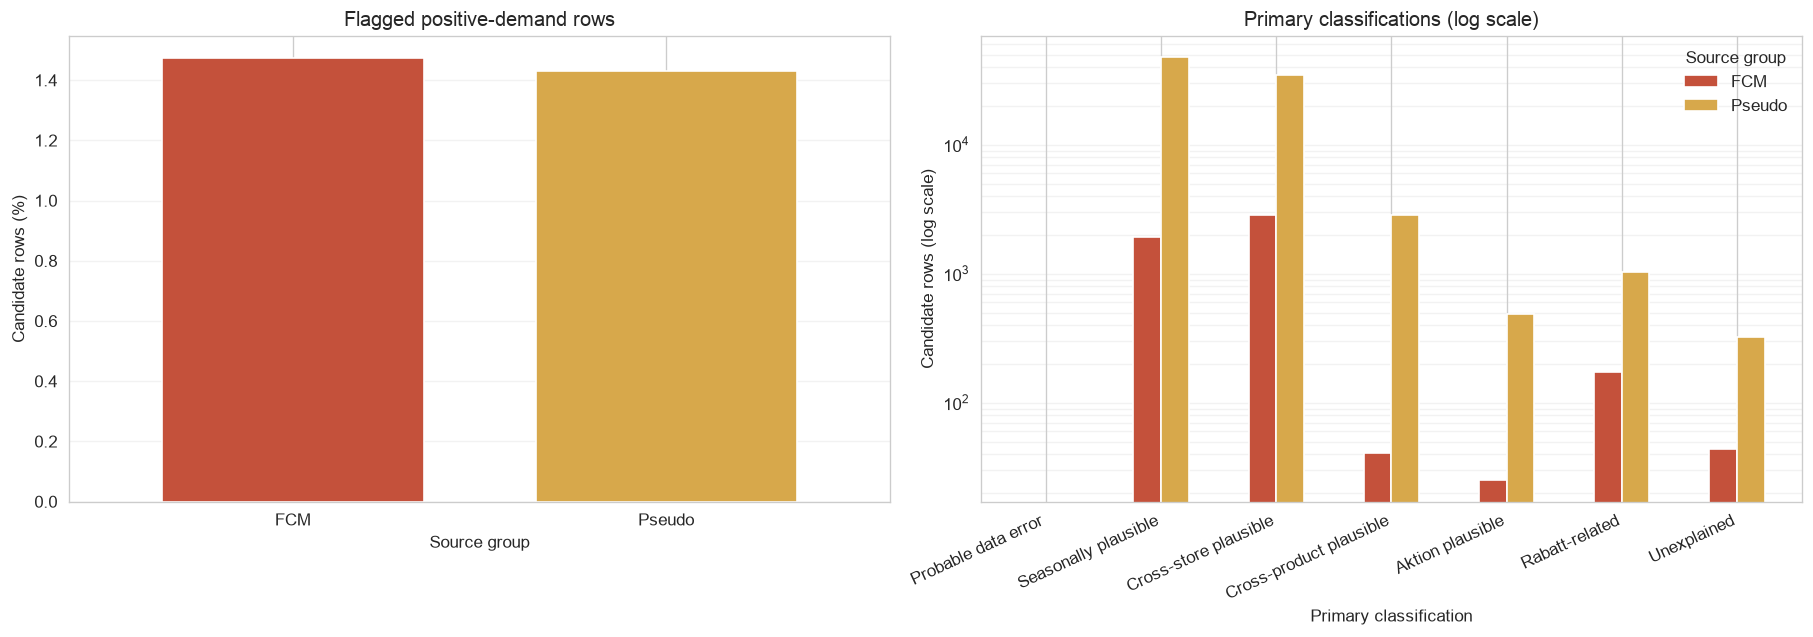

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

rate_plot = group_summary.set_index("source_group")["candidate_row_rate"].reindex(GROUP_ORDER) * 100
rate_plot.plot.bar(
    ax=axes[0], color=[GROUP_COLORS[group] for group in GROUP_ORDER], width=0.7
)
axes[0].set_title("Flagged positive-demand rows")
axes[0].set_xlabel("Source group")
axes[0].set_ylabel("Candidate rows (%)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.25)

x_positions = np.arange(len(CLASS_ORDER))
bar_width = 0.24
for group_number, group_name in enumerate(GROUP_ORDER):
    offset = (group_number - (len(GROUP_ORDER) - 1) / 2) * bar_width
    axes[1].bar(
        x_positions + offset,
        classification_counts.loc[group_name, CLASS_ORDER].to_numpy(),
        width=bar_width, label=group_name, color=GROUP_COLORS[group_name],
    )
axes[1].set_yscale("log")
axes[1].set_title("Primary classifications (log scale)")
axes[1].set_xlabel("Primary classification")
axes[1].set_ylabel("Candidate rows (log scale)")
axes[1].set_xticks(x_positions, CLASS_ORDER, rotation=25, ha="right")
axes[1].legend(frameon=False, title="Source group")
axes[1].grid(axis="y", which="both", alpha=0.25)

display_figure(fig)

## Review lists

These compact lists separate decisions from evidence. The probable-error table contains the reviewed keys that remain after upstream filtering. A separate Rabatt table shows the original demand, 95th-percentile cap, and reduction; other tables retain Aktion, cross-store, cross-product, calendar, and unexplained context. The complete row-level result, including every evidence flag and cleaning action, remains available in `outlier_catalog`.

In [44]:
review_columns = [
    "source_group", "MANDANT_ID", "ARTIKEL_ID", "MARKT_ID", "period",
    "product_name", "sales_unit", "demand", "upper_fence", "rabatt_cap",
    "cleaning_action", "adjusted_demand",
    "weekday_name", "next_holiday_name", "days_to_next_holiday",
    "previous_holiday_name", "days_since_previous_holiday",
    "zero_gap_before_days", "zero_gap_after_days",
    "evidence_summary",
    "median_positive", "second_largest_demand",
    "fence_multiple", "median_multiple", "second_largest_multiple",
]

holiday_explainability = con.execute(f"""
WITH explained AS (
    SELECT
        source_group, MANDANT_ID, ARTIKEL_ID, MARKT_ID, period,
        CASE
            WHEN days_to_next_holiday BETWEEN 0 AND pre_holiday_window_days
                THEN 'before'
            WHEN days_since_previous_holiday BETWEEN 0 AND {POST_HOLIDAY_WINDOW_DAYS}
                THEN 'after'
        END AS holiday_relation,
        CASE
            WHEN days_to_next_holiday BETWEEN 0 AND pre_holiday_window_days
                THEN next_holiday_name
            WHEN days_since_previous_holiday BETWEEN 0 AND {POST_HOLIDAY_WINDOW_DAYS}
                THEN previous_holiday_name
        END AS holiday_name
    FROM classified_candidates
)
SELECT
    source_group, MANDANT_ID, holiday_relation, holiday_name,
    COUNT(*) AS candidate_rows,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
    COUNT(DISTINCT YEAR(period)) AS represented_years
FROM explained
WHERE holiday_relation IS NOT NULL
GROUP BY source_group, MANDANT_ID, holiday_relation, holiday_name
ORDER BY candidate_rows DESC
""").fetchdf()
print("Holiday-window explanations among candidate rows (top 20):")
display(holiday_explainability.head(20).style.format({
    "candidate_rows": "{:,.0f}", "series": "{:,.0f}",
    "represented_years": "{:,.0f}",
}))

probable_errors = (
    outlier_catalog[outlier_catalog["classification"] == "Probable data error"]
    .sort_values("fence_multiple", ascending=False)
)
print(f"Probable data errors: {len(probable_errors):,} rows (top 30 shown)")
display(probable_errors[review_columns].head(30).style.format({
    "demand": "{:,.3f}", "upper_fence": "{:,.3f}", "rabatt_cap": "{:,.3f}",
    "adjusted_demand": "{:,.3f}",
    "median_positive": "{:,.3f}", "second_largest_demand": "{:,.3f}",
    "fence_multiple": "{:,.1f}×", "median_multiple": "{:,.1f}×",
    "second_largest_multiple": "{:,.1f}×",
}))

plausibility_classes = [
    "Aktion plausible", "Rabatt-related",
    "Cross-store plausible", "Cross-product plausible"
]
plausibility_columns = [
    "classification", "source_group", "MANDANT_ID",
    "ARTIKEL_ID", "MARKT_ID", "period",
    "product_name", "demand", "action_flag", "discount_flag",
    "elevated_stores_in_window", "elevated_related_products_in_window",
    "fence_multiple", "median_multiple", "second_largest_multiple",
    "evidence_summary",
]
plausibility_review = (
    outlier_catalog[outlier_catalog["classification"].isin(plausibility_classes)]
    .sort_values(["classification", "fence_multiple"], ascending=[True, False])
    .groupby("classification", sort=False).head(10)
)
print("Aktion, Rabatt, cross-store, and cross-product explanations (top 10 per class):")
display(plausibility_review[plausibility_columns].style.format({
    "demand": "{:,.3f}", "fence_multiple": "{:,.1f}×",
    "median_multiple": "{:,.1f}×", "second_largest_multiple": "{:,.1f}×",
    "elevated_stores_in_window": "{:,.0f}",
    "elevated_related_products_in_window": "{:,.0f}",
}))

rabatt_caps = (
    outlier_catalog[outlier_catalog["cleaning_action"] == "Cap Rabatt at positive-demand P95"]
    .assign(reduction_kg=lambda frame: frame["demand"] - frame["adjusted_demand"])
    .sort_values("reduction_kg", ascending=False)
)
rabatt_impact = pd.DataFrame({
    "capped_rows": [len(rabatt_caps)],
    "original_demand_kg": [rabatt_caps["demand"].sum()],
    "adjusted_demand_kg": [rabatt_caps["adjusted_demand"].sum()],
    "reduction_kg": [rabatt_caps["reduction_kg"].sum()],
})
print("Impact of capping Rabatt rows above the series positive-demand P95:")
display(rabatt_impact.style.format({
    "capped_rows": "{:,.0f}", "original_demand_kg": "{:,.1f}",
    "adjusted_demand_kg": "{:,.1f}", "reduction_kg": "{:,.1f}",
}))
display(rabatt_caps[[
    "source_group", "ARTIKEL_ID", "MARKT_ID", "period", "product_name",
    "demand", "rabatt_cap", "adjusted_demand", "reduction_kg",
    "action_flag", "evidence_summary",
]].head(20).style.format({
    "demand": "{:,.3f}", "rabatt_cap": "{:,.3f}",
    "adjusted_demand": "{:,.3f}", "reduction_kg": "{:,.3f}",
}))

seasonal_series = con.execute("""
SELECT
    source_group, ANY_VALUE(MANDANT_ID) AS MANDANT_ID,
    ARTIKEL_ID, MARKT_ID, ANY_VALUE(product_name) AS product_name,
    ANY_VALUE(sales_unit) AS sales_unit, COUNT(*) AS candidate_dates,
    COUNT(DISTINCT EXTRACT(YEAR FROM period)) AS candidate_years,
    MIN(period) AS first_candidate, MAX(period) AS last_candidate,
    MAX(demand) AS maximum_candidate_demand,
    MAX(seasonal_rate_lift) AS maximum_seasonal_rate_lift
FROM classified_candidates
WHERE classification = 'Seasonally plausible'
GROUP BY source_group, ARTIKEL_ID, MARKT_ID
ORDER BY candidate_years DESC, candidate_dates DESC, maximum_seasonal_rate_lift DESC
""").fetchdf()
print(f"Seasonally plausible series: {len(seasonal_series):,} (top 20 shown)")
display(seasonal_series.head(20).style.format({
    "candidate_dates": "{:,.0f}", "candidate_years": "{:,.0f}",
    "maximum_candidate_demand": "{:,.3f}",
    "maximum_seasonal_rate_lift": "{:.1f}×",
}))

unexplained = (
    outlier_catalog[outlier_catalog["classification"] == "Unexplained"]
    .sort_values("fence_multiple", ascending=False)
)
print(f"Unexplained candidates: {len(unexplained):,} rows (top 30 shown)")
display(unexplained[review_columns].head(30).style.format({
    "demand": "{:,.3f}", "upper_fence": "{:,.3f}", "rabatt_cap": "{:,.3f}",
    "median_positive": "{:,.3f}", "second_largest_demand": "{:,.3f}",
    "fence_multiple": "{:,.1f}×", "median_multiple": "{:,.1f}×",
    "second_largest_multiple": "{:,.1f}×",
}))

Holiday-window explanations among candidate rows (top 20):


,source_group,MANDANT_ID,holiday_relation,holiday_name,candidate_rows,series,represented_years
0,Pseudo,110,before,Erster Mai,"2,446","1,315",3
1,Pseudo,110,before,Erster Weihnachtstag,"1,982",966,3
2,Pseudo,110,before,Karfreitag,"1,594","1,100",3
3,Pseudo,110,before,Pfingstmontag,"1,528",946,3
4,Pseudo,130,before,Erster Weihnachtstag,"1,511",479,3
5,Pseudo,110,before,Ostermontag,"1,334",926,3
6,Pseudo,125,before,Erster Mai,"1,066",703,3
7,Pseudo,110,before,Christi Himmelfahrt,"1,024",743,3
8,Pseudo,130,before,Erster Mai,962,529,3
9,Pseudo,130,before,Karfreitag,922,575,3


Probable data errors: 0 rows (top 30 shown)


,source_group,MANDANT_ID,ARTIKEL_ID,MARKT_ID,period,product_name,sales_unit,demand,upper_fence,rabatt_cap,cleaning_action,adjusted_demand,weekday_name,next_holiday_name,days_to_next_holiday,previous_holiday_name,days_since_previous_holiday,zero_gap_before_days,zero_gap_after_days,evidence_summary,median_positive,second_largest_demand,fence_multiple,median_multiple,second_largest_multiple


Aktion, Rabatt, cross-store, and cross-product explanations (top 10 per class):


...

,source_group,ARTIKEL_ID,MARKT_ID,period,product_name,demand,rabatt_cap,adjusted_demand,reduction_kg,action_flag,evidence_summary
87531,Pseudo,316842,1300002,2024-11-28 00:00:00,Kasseler-Nacken am Stück,461.549,42.666,42.666,418.883,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 13 related products elevated within +/-3 days
52827,Pseudo,316842,1300002,2024-11-29 00:00:00,Kasseler-Nacken am Stück,233.717,42.666,42.666,191.051,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 46 stores elevated within +/-3 days; 15 related products elevated within +/-3 days
5879,Pseudo,317119,1300021,2026-05-23 00:00:00,Schweinerückensteaks mariniert,184.892,49.648,49.648,135.244,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 126 stores elevated within +/-3 days; 17 related products elevated within +/-3 days; Holiday window: 2 days before Pfingstmontag (2 candidate year(s))
9796,Pseudo,317123,1300009,2024-04-30 00:00:00,"Nackensteak mariniert, vom Schwein",219.944,85.517,85.517,134.427,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 141 stores elevated within +/-3 days; 19 related products elevated within +/-3 days; Holiday window: 1 days before Erster Mai (3 candidate year(s))
7398,Pseudo,316623,1300023,2025-04-14 00:00:00,Hackfleisch gemischt Schwein und Rind,283.328,150.573,150.573,132.755,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 20 stores elevated within +/-3 days; 18 related products elevated within +/-3 days; Holiday window: 4 days before Karfreitag (1 candidate year(s))
5848,Pseudo,317123,1100045,2025-04-19 00:00:00,"Nackensteak mariniert, vom Schwein",184.658,51.913,51.913,132.745,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 155 stores elevated within +/-3 days; 22 related products elevated within +/-3 days; Holiday window: 2 days before Ostermontag (3 candidate year(s))
5922,Pseudo,317123,1100045,2026-05-23 00:00:00,"Nackensteak mariniert, vom Schwein",181.180,51.913,51.913,129.267,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 149 stores elevated within +/-3 days; 17 related products elevated within +/-3 days; Holiday window: 2 days before Pfingstmontag (2 candidate year(s))
5070,Pseudo,1293322,1300005,2026-05-23 00:00:00,SB GV Nackensteak vom Schwein Kräuter,137.198,12.611,12.611,124.587,0,RABATT = 1; cap at series positive-demand 95th percentile; 18 stores elevated within +/-3 days; 16 related products elevated within +/-3 days; Holiday window: 2 days before Pfingstmontag (1 candidate year(s))
5896,Pseudo,317123,1100046,2025-04-19 00:00:00,"Nackensteak mariniert, vom Schwein",172.628,50.017,50.017,122.611,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 155 stores elevated within +/-3 days; 11 related products elevated within +/-3 days; Holiday window: 2 days before Ostermontag (1 candidate year(s))
5590,Pseudo,317157,1100018,2025-04-30 00:00:00,"Bauchscheiben gewürzt, vom Schwein",153.914,34.046,34.046,119.868,1,AKTION_KENNZEICHEN = 1; RABATT = 1; cap at series positive-demand 95th percentile; 146 stores elevated within +/-3 days; 15 related products elevated within +/-3 days; Holiday window: 1 days before Erster Mai (3 candidate year(s))


Seasonally plausible series: 12,223 (top 20 shown)


,source_group,MANDANT_ID,ARTIKEL_ID,MARKT_ID,product_name,sales_unit,candidate_dates,candidate_years,first_candidate,last_candidate,maximum_candidate_demand,maximum_seasonal_rate_lift
0,Pseudo,130,317045,1300019,"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",kg,61,4,2023-09-26 00:00:00,2026-05-30 00:00:00,108.509,1.2×
1,Pseudo,110,330043,1100018,Kasseler Nacken ohne Knochen,kg,50,4,2023-10-02 00:00:00,2026-03-14 00:00:00,47.014,3.2×
2,Pseudo,130,316872,1300021,Kasseler-Lachsbraten,kg,48,4,2023-10-02 00:00:00,2026-03-30 00:00:00,72.119,2.4×
3,Pseudo,130,317045,1300028,"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",kg,47,4,2023-09-26 00:00:00,2026-05-28 00:00:00,71.816,1.4×
4,Pseudo,130,317045,1300012,"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",kg,46,4,2023-09-28 00:00:00,2026-05-30 00:00:00,112.691,1.5×
5,Pseudo,130,317045,1300025,"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",kg,45,4,2023-09-26 00:00:00,2026-05-29 00:00:00,130.816,1.4×
6,Pseudo,130,317045,1300023,"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",kg,44,4,2023-09-26 00:00:00,2026-05-28 00:00:00,110.850,1.6×
7,Pseudo,110,330043,1100019,Kasseler Nacken ohne Knochen,kg,43,4,2023-10-02 00:00:00,2026-01-31 00:00:00,84.845,2.8×
8,Pseudo,130,316872,1300025,Kasseler-Lachsbraten,kg,43,4,2023-10-02 00:00:00,2026-04-02 00:00:00,55.676,2.3×
9,Pseudo,130,317045,1300014,"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",kg,43,4,2023-09-26 00:00:00,2026-05-29 00:00:00,91.763,1.7×


Unexplained candidates: 370 rows (top 30 shown)


,source_group,MANDANT_ID,ARTIKEL_ID,MARKT_ID,period,product_name,sales_unit,demand,upper_fence,rabatt_cap,cleaning_action,adjusted_demand,weekday_name,next_holiday_name,days_to_next_holiday,previous_holiday_name,days_since_previous_holiday,zero_gap_before_days,zero_gap_after_days,evidence_summary,median_positive,second_largest_demand,fence_multiple,median_multiple,second_largest_multiple
91883,Pseudo,135,316872,1350054,2024-05-28 00:00:00,Kasseler-Lachsbraten,kg,22.477,6.580,3.185,Retain,22.477000,Tuesday,Tag der Deutschen Einheit,128,Pfingstmontag,8,5,0,,0.762,8.744,3.4×,29.5×,2.6×
91884,Pseudo,135,317121,1350059,2023-09-14 00:00:00,Nackensteak vom Schwein,kg,20.000,6.150,4.606,Retain,20.000000,Thursday,Tag der Deutschen Einheit,19,Pfingstmontag,108,5,4,,0.788,12.521,3.3×,25.4×,1.6×
91885,Pseudo,115,1215070,1150009,2025-11-15 00:00:00,HofWerte Filet vom Rind,kg,6.280,2.054,0.946,Retain,6.280000,Saturday,Erster Weihnachtstag,40,Reformationstag,15,0,1,,0.332,1.678,3.1×,18.9×,3.7×
91886,Pseudo,120,317167,1200037,2025-11-20 00:00:00,"Hüftsteak gewürzt, vom Rind",kg,9.682,3.354,1.616,Retain,9.682000,Thursday,Erster Weihnachtstag,35,Reformationstag,20,5,1,,0.486,4.066,2.9×,19.9×,2.4×
91887,Pseudo,135,316646,1350056,2024-11-12 00:00:00,Grobe Bratwurst vom Schwein,kg,8.905,3.097,1.104,Retain,8.905000,Tuesday,Erster Weihnachtstag,43,Reformationstag,12,0,0,,0.493,3.667,2.9×,18.1×,2.4×
91888,Pseudo,125,1203487,1250060,2023-08-05 00:00:00,Hofwerte Nackensteak Kräuter vom Schwein,kg,11.765,4.302,1.863,Retain,11.765000,Saturday,Tag der Deutschen Einheit,59,Pfingstmontag,68,,8,,0.622,3.097,2.7×,18.9×,3.8×
91889,Pseudo,125,318346,1250034,2023-09-13 00:00:00,Rückensteak natur vom Schwein,kg,11.655,4.400,5.617,Retain,11.655000,Wednesday,Tag der Deutschen Einheit,20,Pfingstmontag,107,10,2,,0.643,11.313,2.6×,18.1×,1.0×
91890,Pseudo,130,1405414,1300023,2026-01-31 00:00:00,"Rindersaftschinken mit Meerrettich, ""Schröder""",kg,2.380,0.945,0.675,Retain,2.380000,Saturday,Karfreitag,62,Neujahr,30,0,1,,0.151,1.237,2.5×,15.8×,1.9×
91891,Pseudo,110,318346,1100054,2024-02-28 00:00:00,Rückensteak natur vom Schwein,kg,8.305,3.393,1.991,Retain,8.305000,Wednesday,Karfreitag,30,Neujahr,58,0,1,,0.526,6.037,2.4×,15.8×,1.4×
4998,FCM,120,1382863,1200005,2025-09-13 00:00:00,Rostbratwurst (eigene Herstellung),kg,8.151,3.504,2.283,Retain,8.151000,Saturday,Tag der Deutschen Einheit,20,Pfingstmontag,96,0,1,,0.518,3.728,2.3×,15.7×,2.2×


## Representative series

Representative examples favor different source groups where each class permits it. Every series receives its own full-width horizontal line. The plots retain the complete daily history, including zeros, and overlay only the flagged dates; the fence itself is calculated only from positive demand. A purple background band is drawn only when a displayed candidate dot falls inside that holiday window. Cross-store and cross-product examples use a local ±21-day view with one vertically separated row per store or product. Each row is normalized to its own local maximum for shape comparison; its absolute maximum remains in the row label, candidate dates are marked, and the ±3-day detection window is shaded.

,example_class,example_rank,anchor_period,source_group,MANDANT_ID,ARTIKEL_ID,MARKT_ID,WGR_ID,product_name,sales_unit,store_label
0,Seasonally plausible,1,2026-04-09,FCM,110,1406587,1100074,890,SB Snirtje Braten vom Schwein,kg,Filiale A
1,Seasonally plausible,2,2025-04-15,Pseudo,130,318346,1300005,890,Rückensteak natur vom Schwein,kg,Filiale B
2,Cross-store plausible,1,2025-12-10,FCM,110,1406063,1100063,900,SB Fleischkäse roh in Schale,kg,Filiale C
3,Cross-store plausible,2,2024-12-05,Pseudo,110,316835,1100001,890,Lachsbraten am Stück vom Schwein,kg,Filiale D
4,Cross-product plausible,1,2025-11-18,FCM,130,1406593,1300013,890,SB Schweine Rouladen gefüllt,kg,Filiale E
5,Cross-product plausible,2,2024-06-28,Pseudo,130,1293322,1300013,890,SB GV Nackensteak vom Schwein Kräuter,kg,Filiale F
6,Aktion plausible,1,2026-01-22,FCM,120,1382770,1200012,900,Pizzafleischkäse ofengebacken,kg,Filiale G
7,Aktion plausible,2,2025-07-26,Pseudo,110,1367847,1100035,890,GV Oberschalenschnitzel vom Schwein,kg,Filiale H
8,Rabatt-related,1,2026-02-23,FCM,110,1413150,1100011,900,Roastbeef-Aufschnitt mit Pfeffer,kg,Filiale I
9,Rabatt-related,2,2024-10-12,Pseudo,120,316688,1200003,890,Markknochen Rind,kg,Filiale J


Evidence context for the plotted candidate dates:


,example_class,example_rank,MANDANT_ID,period,weekday_name,demand,point_class,action_flag,discount_flag,zero_gap_before_days,zero_gap_after_days,elevated_stores_in_window,elevated_related_products_in_window,next_holiday_name,days_to_next_holiday,previous_holiday_name,days_since_previous_holiday,evidence_summary
5,Seasonally plausible,1,110,2025-10-02 00:00:00,Thursday,3.142,Seasonally plausible,0,0,1,1,16,3,Tag der Deutschen Einheit,1,Pfingstmontag,115,16 stores elevated within +/-3 days; 3 related products elevated within +/-3 days; Holiday window: 1 days before Tag der Deutschen Einheit (1 candidate year(s))
10,Seasonally plausible,1,110,2025-10-09 00:00:00,Thursday,2.068,Seasonally plausible,0,0,4,0,5,1,Reformationstag,22,Tag der Deutschen Einheit,6,5 stores elevated within +/-3 days; Holiday window: 6 days after Tag der Deutschen Einheit (1 candidate year(s))
11,Seasonally plausible,1,110,2025-10-10 00:00:00,Friday,2.150,Seasonally plausible,0,0,0,5,6,2,Reformationstag,21,Tag der Deutschen Einheit,7,6 stores elevated within +/-3 days; Holiday window: 7 days after Tag der Deutschen Einheit (1 candidate year(s))
16,Seasonally plausible,1,110,2025-10-16 00:00:00,Thursday,2.172,Cross-store plausible,0,0,5,7,5,3,Reformationstag,15,Tag der Deutschen Einheit,13,5 stores elevated within +/-3 days; 3 related products elevated within +/-3 days
33,Seasonally plausible,1,110,2025-11-06 00:00:00,Thursday,3.048,Seasonally plausible,0,0,11,0,7,3,Erster Weihnachtstag,49,Reformationstag,6,7 stores elevated within +/-3 days; 3 related products elevated within +/-3 days; Holiday window: 6 days after Reformationstag (1 candidate year(s))
41,Seasonally plausible,1,110,2025-11-15 00:00:00,Saturday,3.138,Cross-store plausible,0,0,7,1,11,2,Erster Weihnachtstag,40,Reformationstag,15,11 stores elevated within +/-3 days
71,Seasonally plausible,1,110,2025-12-20 00:00:00,Saturday,2.062,Seasonally plausible,0,0,2,1,7,6,Erster Weihnachtstag,5,Reformationstag,50,7 stores elevated within +/-3 days; 6 related products elevated within +/-3 days; Holiday window: 5 days before Erster Weihnachtstag (1 candidate year(s))
116,Seasonally plausible,1,110,2026-02-14 00:00:00,Saturday,2.088,Cross-store plausible,0,0,0,5,6,2,Karfreitag,48,Neujahr,44,6 stores elevated within +/-3 days
121,Seasonally plausible,1,110,2026-02-20 00:00:00,Friday,2.186,Cross-store plausible,0,0,5,0,5,3,Karfreitag,42,Neujahr,50,5 stores elevated within +/-3 days; 3 related products elevated within +/-3 days
146,Seasonally plausible,1,110,2026-03-21 00:00:00,Saturday,2.094,Cross-store plausible,0,0,7,1,8,4,Karfreitag,13,Neujahr,79,8 stores elevated within +/-3 days; 4 related products elevated within +/-3 days


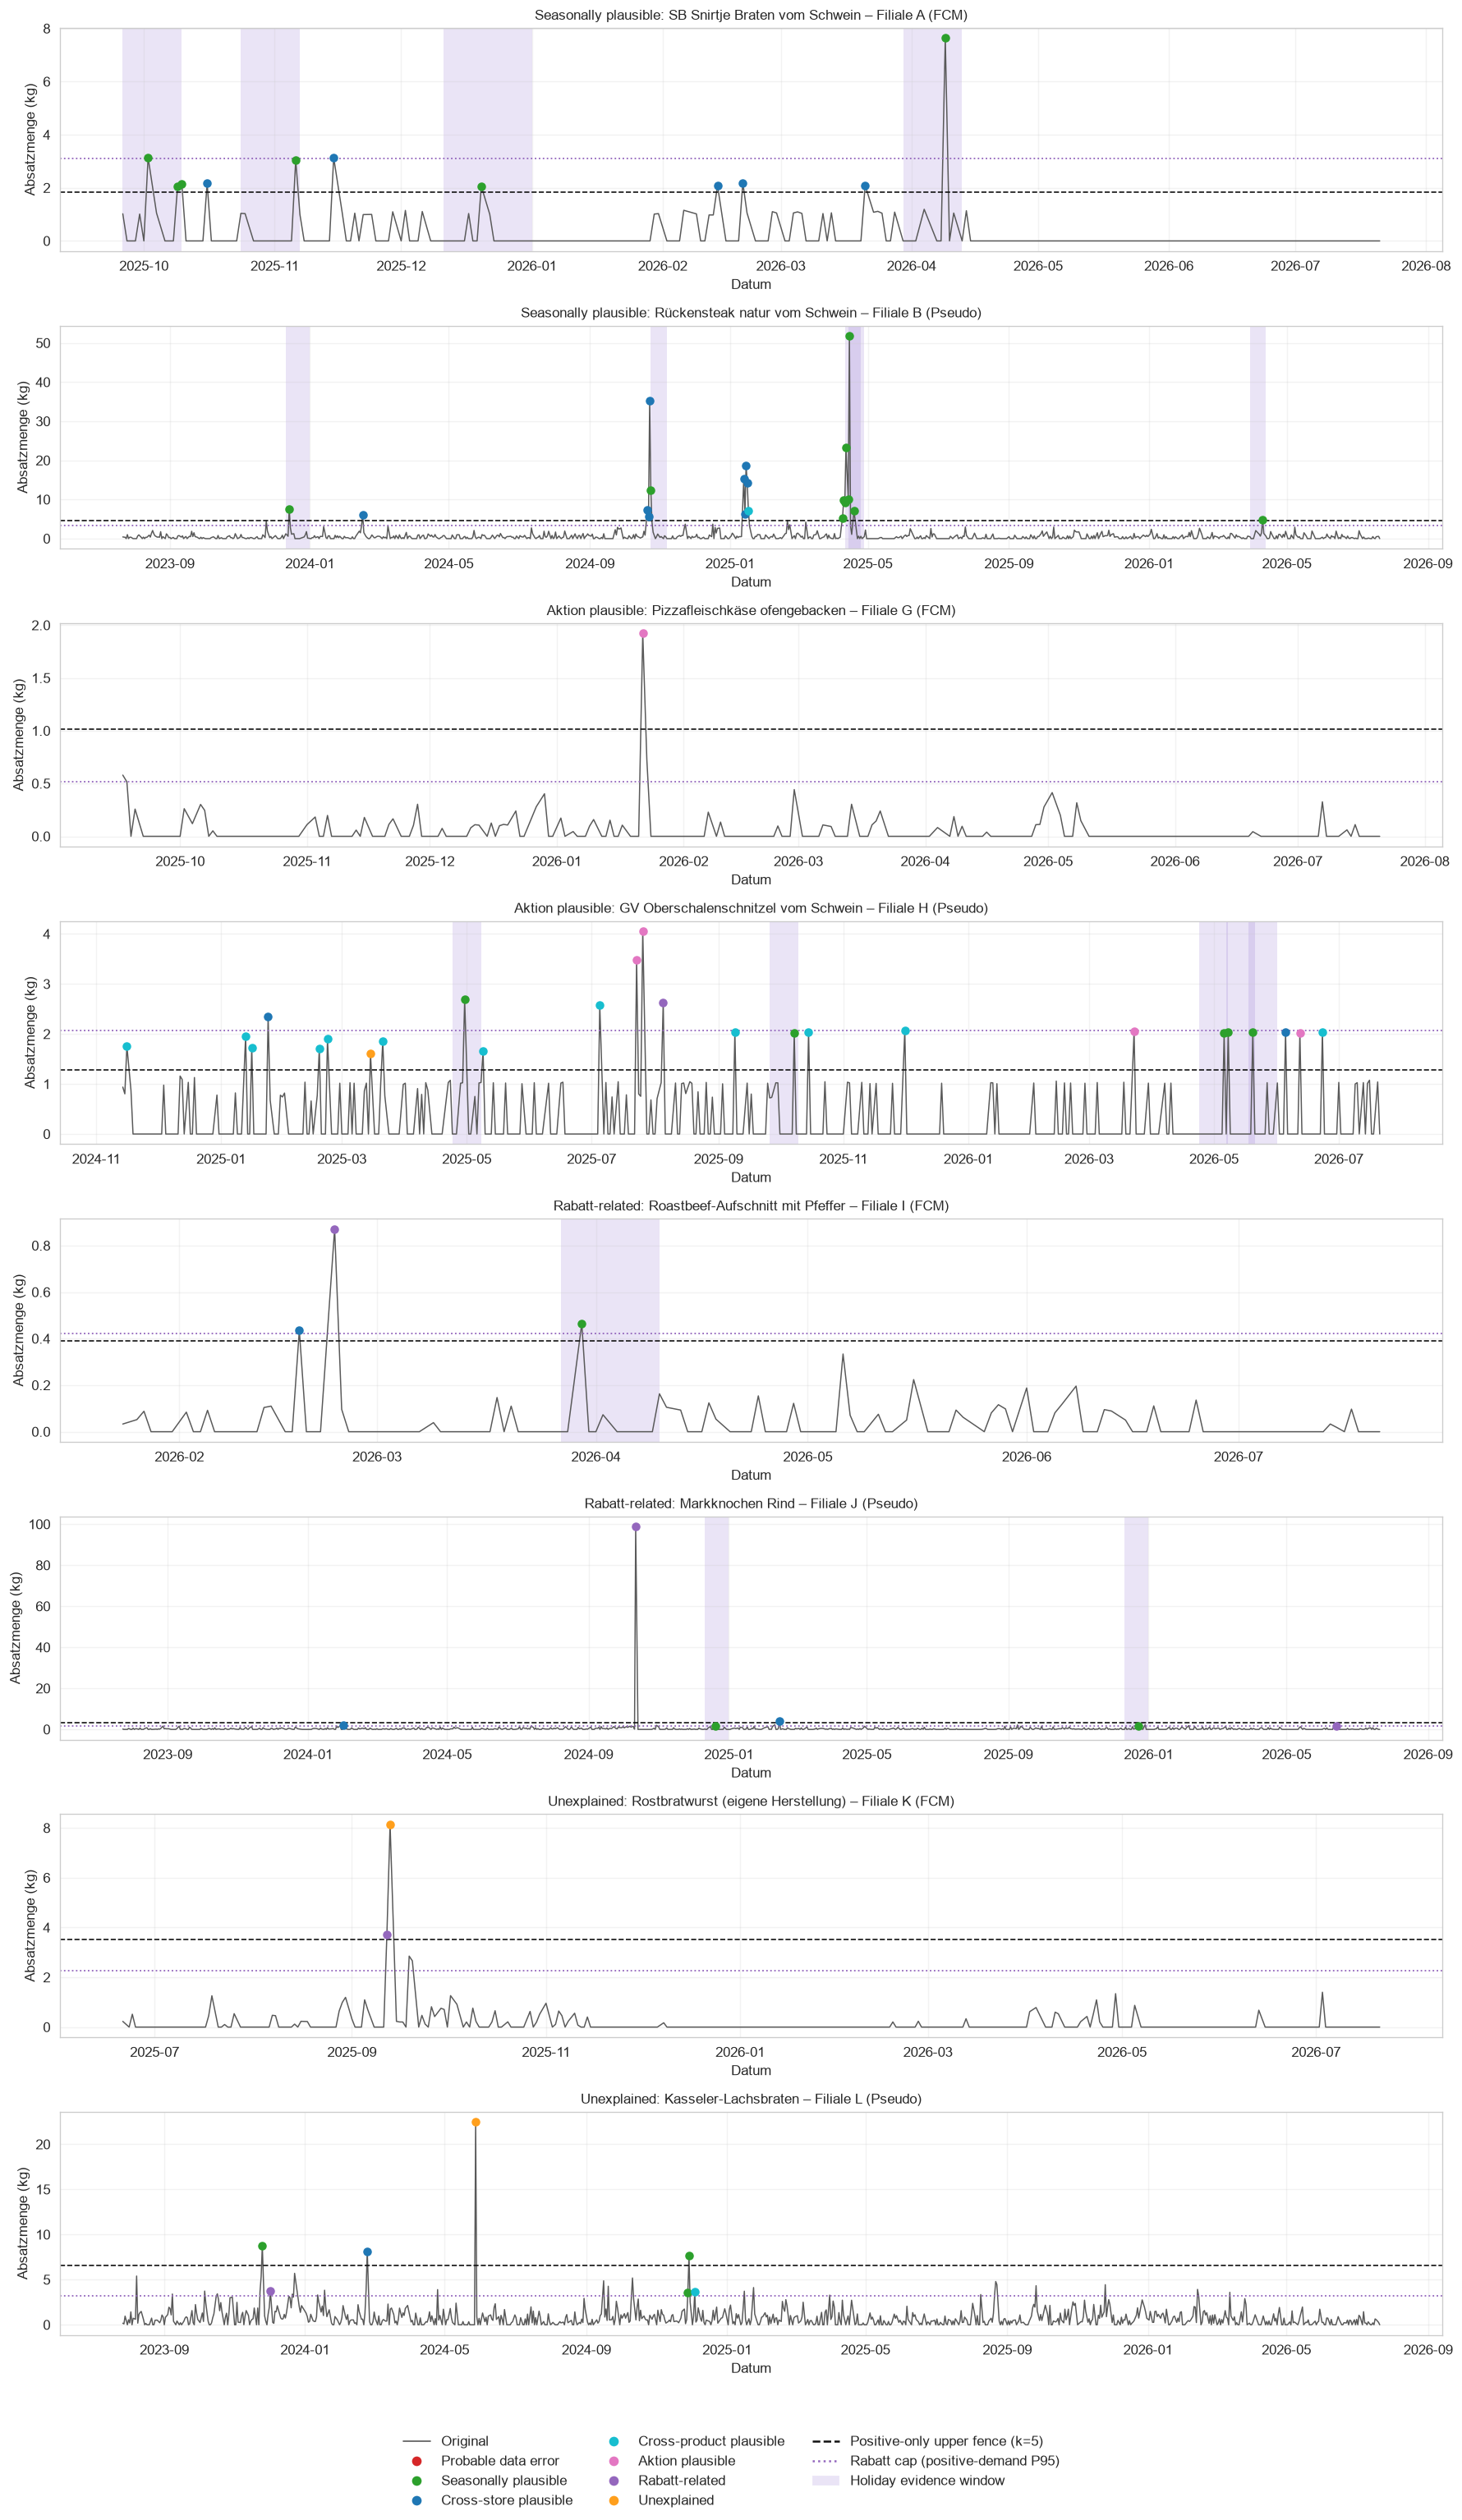

/var/folders/v7/49xgv42x7ld3hqhjfsrsp1lh0000gn/T/ipykernel_68607/2019438838.py:344: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout(rect=(0, 0.05, 1, 1))
/var/folders/v7/49xgv42x7ld3hqhjfsrsp1lh0000gn/T/ipykernel_68607/3009347363.py:73: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")


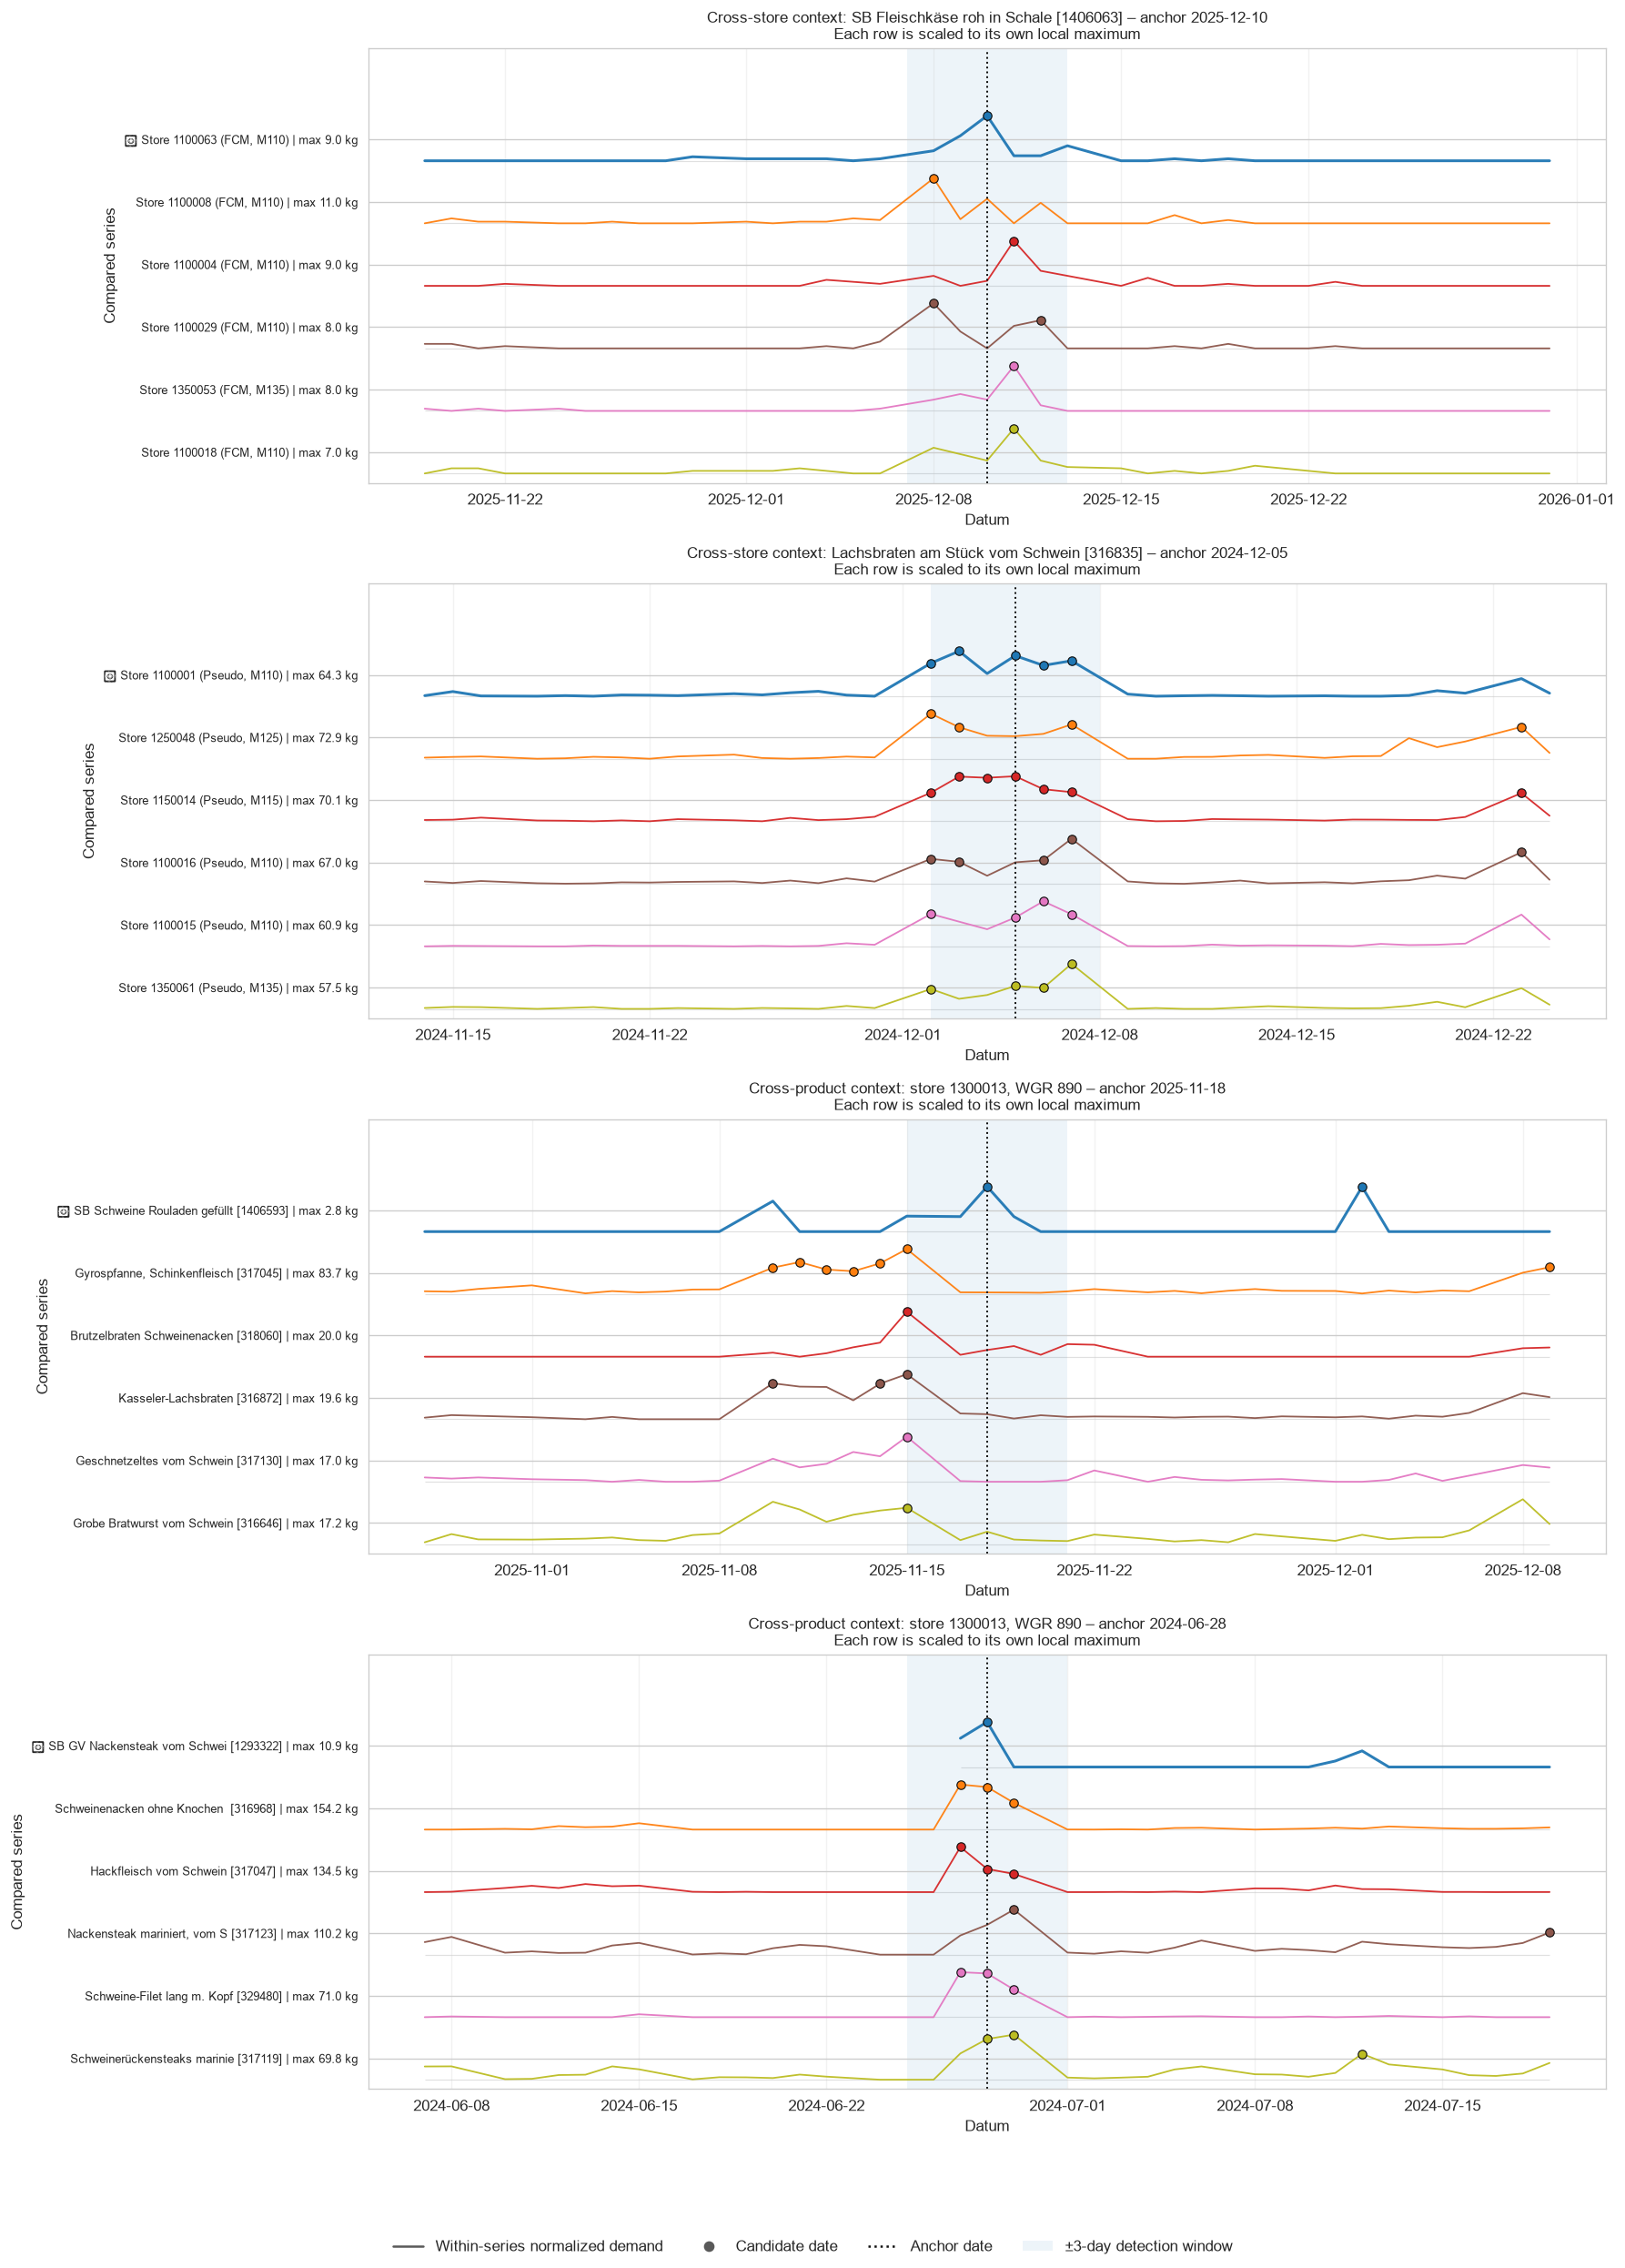

In [45]:
EXAMPLES_PER_CLASS = 2
SERIES_KEYS = ["source_group", "ARTIKEL_ID", "MARKT_ID"]
selected_series = set()
selected_source_counts = {group: 0 for group in GROUP_ORDER}

def select_example_series(frame, sort_by, ascending=False, n=EXAMPLES_PER_CLASS):
    ordered = frame.sort_values(sort_by, ascending=ascending).drop_duplicates(SERIES_KEYS)
    available = ordered[
        ~ordered[SERIES_KEYS].apply(tuple, axis=1).isin(selected_series)
    ]
    chosen_indices = []
    source_priority = sorted(GROUP_ORDER, key=lambda group: selected_source_counts[group])
    for group in source_priority:
        group_rows = available[available["source_group"] == group]
        if not group_rows.empty and len(chosen_indices) < n:
            chosen_indices.append(group_rows.index[0])
    if len(chosen_indices) < n:
        remainder = available.drop(index=chosen_indices, errors="ignore")
        chosen_indices.extend(remainder.head(n - len(chosen_indices)).index)
    available = available.loc[chosen_indices]
    selected_series.update(available[SERIES_KEYS].apply(tuple, axis=1))
    for group, count in available["source_group"].value_counts().items():
        selected_source_counts[group] += int(count)
    return available

example_frames = []
error_examples = select_example_series(
    probable_errors, "fence_multiple", n=EXAMPLES_PER_CLASS
)
if not error_examples.empty:
    example_frames.append(error_examples)
holiday_seasonal = outlier_catalog[
    (outlier_catalog["classification"] == "Seasonally plausible")
    & (
        (outlier_catalog["days_to_next_holiday"] <= outlier_catalog["pre_holiday_window_days"])
        | (outlier_catalog["days_since_previous_holiday"] <= POST_HOLIDAY_WINDOW_DAYS)
    )
]
for class_name, sort_by in [
    ("Aktion plausible", "fence_multiple"),
    ("Rabatt-related", "fence_multiple"),
    ("Cross-store plausible", "elevated_stores_in_window"),
    ("Cross-product plausible", "elevated_related_products_in_window"),
]:
    class_examples = select_example_series(
        outlier_catalog[outlier_catalog["classification"] == class_name], sort_by
    )
    if not class_examples.empty:
        example_frames.append(class_examples)

seasonal_examples = select_example_series(holiday_seasonal, "fence_multiple")
if len(seasonal_examples) < EXAMPLES_PER_CLASS:
    seasonal_fallback = outlier_catalog[
        outlier_catalog["classification"] == "Seasonally plausible"
    ]
    supplement = select_example_series(
        seasonal_fallback, "fence_multiple", n=EXAMPLES_PER_CLASS - len(seasonal_examples)
    )
    seasonal_examples = pd.concat([seasonal_examples, supplement], ignore_index=True)
if not seasonal_examples.empty:
    example_frames.append(seasonal_examples)

unexplained_examples = select_example_series(unexplained, "fence_multiple")
if not unexplained_examples.empty:
    example_frames.append(unexplained_examples)

representative_keys = pd.concat(example_frames, ignore_index=True)[
    ["classification", *SERIES_KEYS, "period", "WGR_ID"]
].drop_duplicates(SERIES_KEYS).rename(columns={"period": "anchor_period"})
representative_keys["classification"] = pd.Categorical(
    representative_keys["classification"], CLASS_ORDER, ordered=True
)
representative_keys = representative_keys.sort_values("classification")
representative_keys["example_rank"] = (
    representative_keys.groupby("classification", observed=True).cumcount() + 1
)
con.register("representative_keys", representative_keys)

representative_series = con.execute("""
SELECT
    k.classification AS example_class, k.example_rank, k.anchor_period, k.WGR_ID,
    s.source_group, s.MANDANT_ID, s.ARTIKEL_ID, s.MARKT_ID, s.period,
    s.product_name, s.sales_unit, s.demand, b.upper_fence, b.rabatt_cap,
    c.classification AS point_class, c.weekday_name, c.calendar_explanation,
    c.next_holiday_date, c.next_holiday_name, c.days_to_next_holiday,
    c.pre_holiday_window_days,
    c.previous_holiday_date, c.previous_holiday_name, c.days_since_previous_holiday,
    c.pre_holiday_candidate_years, c.post_holiday_candidate_years,
    c.action_flag, c.discount_flag, c.zero_gap_before_days, c.zero_gap_after_days,
    c.elevated_stores_in_window, c.elevated_related_products_in_window,
    c.evidence_summary
FROM representative_keys k
JOIN daily_rows s USING (source_group, ARTIKEL_ID, MARKT_ID)
JOIN peak_context b USING (source_group, ARTIKEL_ID, MARKT_ID)
LEFT JOIN classified_candidates c
  ON s.source_group = c.source_group
 AND s.ARTIKEL_ID = c.ARTIKEL_ID
 AND s.MARKT_ID = c.MARKT_ID
 AND s.period = c.period
ORDER BY k.classification, k.example_rank, s.period
""").fetchdf()
representative_series["period"] = pd.to_datetime(representative_series["period"])
representative_series["anchor_period"] = pd.to_datetime(representative_series["anchor_period"])
representative_series["next_holiday_date"] = pd.to_datetime(representative_series["next_holiday_date"])
representative_series["previous_holiday_date"] = pd.to_datetime(representative_series["previous_holiday_date"])

lookup = representative_series.groupby(
    ["example_class", "example_rank"], sort=False, observed=True
).first().reset_index()[
    ["example_class", "example_rank", "anchor_period",
     "source_group", "MANDANT_ID",
     "ARTIKEL_ID",
     "MARKT_ID", "WGR_ID", "product_name", "sales_unit"]
]
lookup["store_label"] = [f"Filiale {chr(ord('A') + i)}" for i in range(len(lookup))]
display(lookup)

representative_evidence_context = (
    representative_series[representative_series["point_class"].notna()]
    [["example_class", "example_rank", "MANDANT_ID", "period", "weekday_name",
      "demand", "point_class", "action_flag", "discount_flag",
      "zero_gap_before_days", "zero_gap_after_days",
      "elevated_stores_in_window", "elevated_related_products_in_window",
      "next_holiday_name", "days_to_next_holiday", "previous_holiday_name",
      "days_since_previous_holiday", "evidence_summary"]]
    .sort_values(["example_class", "example_rank", "period"])
)
print("Evidence context for the plotted candidate dates:")
display(representative_evidence_context.head(80).style.format({"demand": "{:,.3f}"}))

single_lookup = lookup[~lookup["example_class"].isin(
    ["Cross-store plausible", "Cross-product plausible"]
)]
fig, axes = plt.subplots(
    len(single_lookup), 1, figsize=(15, 3.2 * len(single_lookup)), squeeze=False
)

for ax, row in zip(axes[:, 0], single_lookup.itertuples(index=False)):
    series = representative_series[
        (representative_series["example_class"] == row.example_class)
        & (representative_series["example_rank"] == row.example_rank)
    ]
    ax.plot(series["period"], series["demand"], color="0.35", linewidth=0.9, label="Original")
    candidate_points = series[series["point_class"].notna()]
    pre_holidays = candidate_points.loc[
        candidate_points["days_to_next_holiday"]
        .le(candidate_points["pre_holiday_window_days"]),
        ["next_holiday_date", "next_holiday_name"],
    ].set_axis(["holiday_date", "holiday_name"], axis=1)
    post_holidays = candidate_points.loc[
        candidate_points["days_since_previous_holiday"].le(POST_HOLIDAY_WINDOW_DAYS),
        ["previous_holiday_date", "previous_holiday_name"],
    ].set_axis(["holiday_date", "holiday_name"], axis=1)
    relevant_holidays = pd.concat([pre_holidays, post_holidays]).dropna().drop_duplicates()
    for holiday in relevant_holidays.itertuples(index=False):
        pre_days = (CHRISTMAS_PRE_HOLIDAY_WINDOW_DAYS
                    if "Weihnacht" in holiday.holiday_name
                    else PRE_HOLIDAY_WINDOW_DAYS)
        ax.axvspan(
            holiday.holiday_date - pd.Timedelta(days=pre_days),
            holiday.holiday_date + pd.Timedelta(days=POST_HOLIDAY_WINDOW_DAYS),
            color="#6f42c1", alpha=0.14, linewidth=0, zorder=0,
        )
    for point_class in CLASS_ORDER:
        points = series[series["point_class"] == point_class]
        if not points.empty:
            ax.scatter(
                points["period"], points["demand"], s=28, zorder=3,
                color=CLASS_COLORS[point_class], label=point_class,
            )
    ax.axhline(
        series["upper_fence"].iloc[0], color="#111111", linestyle="--",
        linewidth=1.0, label=f"Positive-only upper fence (k={IQR_K:g})",
    )
    ax.axhline(
        series["rabatt_cap"].iloc[0], color="#9467bd", linestyle=":",
        linewidth=1.1, label="Rabatt cap (positive-demand P95)",
    )
    ax.set_title(
        f"{row.example_class}: {str(row.product_name)[:70]} – "
        f"{row.store_label} ({row.source_group})",
        fontsize=10,
    )
    ax.set_ylabel("Absatzmenge (kg)")
    ax.grid(alpha=0.25)
    ax.set_xlabel("Datum")

legend_handles = [
    Line2D([0], [0], color="0.35", linewidth=1.0, label="Original"),
    *[Line2D([0], [0], marker="o", linestyle="None", markersize=6,
             color=CLASS_COLORS[name], label=name) for name in CLASS_ORDER],
    Line2D([0], [0], color="#111111", linestyle="--",
           label=f"Positive-only upper fence (k={IQR_K:g})"),
    Line2D([0], [0], color="#9467bd", linestyle=":",
           label="Rabatt cap (positive-demand P95)"),
    Patch(facecolor="#6f42c1", alpha=0.14, label="Holiday evidence window"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
display_figure(fig)

# Local multi-series context for cross-store and cross-product evidence.
CONTEXT_WINDOW_DAYS = 21
MAX_CONTEXT_SERIES = 6
cross_context = con.execute(f"""
WITH anchor_keys AS (
    SELECT
        CAST(classification AS VARCHAR) AS classification, example_rank,
        source_group AS anchor_source_group, ARTIKEL_ID AS anchor_article_id,
        MARKT_ID AS anchor_market_id, WGR_ID AS anchor_wgr_id,
        CAST(anchor_period AS DATE) AS anchor_period
    FROM representative_keys
    WHERE classification IN ('Cross-store plausible', 'Cross-product plausible')
),
nearby_series AS (
    SELECT
        k.*, c.source_group AS context_source_group,
        c.ARTIKEL_ID AS context_article_id, c.MARKT_ID AS context_market_id,
        MAX(c.demand) AS context_candidate_peak
    FROM anchor_keys k
    JOIN classified_candidates c
      ON ABS(DATE_DIFF('day', k.anchor_period, c.period)) <= {CROSS_SERIES_WINDOW_DAYS}
     AND (
          (k.classification = 'Cross-store plausible'
           AND c.ARTIKEL_ID = k.anchor_article_id)
       OR (k.classification = 'Cross-product plausible'
           AND c.MARKT_ID = k.anchor_market_id
           AND c.WGR_ID = k.anchor_wgr_id)
     )
    GROUP BY ALL
),
ranked_series AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY classification, example_rank
            ORDER BY
                CASE WHEN context_source_group = anchor_source_group
                       AND context_article_id = anchor_article_id
                       AND context_market_id = anchor_market_id
                     THEN 0 ELSE 1 END,
                context_candidate_peak DESC
        ) AS context_rank
    FROM nearby_series
)
SELECT
    n.classification AS example_class, n.example_rank, n.anchor_period,
    n.anchor_article_id, n.anchor_market_id, n.anchor_wgr_id, n.context_rank,
    s.source_group, s.MANDANT_ID, s.ARTIKEL_ID, s.MARKT_ID,
    s.product_name, s.sales_unit, s.period, s.demand,
    p.classification AS point_class
FROM ranked_series n
JOIN daily_rows s
  ON s.source_group = n.context_source_group
 AND s.ARTIKEL_ID = n.context_article_id
 AND s.MARKT_ID = n.context_market_id
LEFT JOIN classified_candidates p
  ON s.source_group = p.source_group
 AND s.ARTIKEL_ID = p.ARTIKEL_ID
 AND s.MARKT_ID = p.MARKT_ID
 AND s.period = p.period
WHERE n.context_rank <= {MAX_CONTEXT_SERIES}
  AND s.period BETWEEN n.anchor_period - INTERVAL {CONTEXT_WINDOW_DAYS} DAY
                   AND n.anchor_period + INTERVAL {CONTEXT_WINDOW_DAYS} DAY
ORDER BY n.classification, n.example_rank, n.context_rank, s.period
""").fetchdf()

cross_context["period"] = pd.to_datetime(cross_context["period"])
cross_context["anchor_period"] = pd.to_datetime(cross_context["anchor_period"])
cross_lookup = lookup[lookup["example_class"].isin(
    ["Cross-store plausible", "Cross-product plausible"]
)]

fig, axes = plt.subplots(
    len(cross_lookup), 1, figsize=(15, 5.2 * len(cross_lookup)), squeeze=False
)
for ax, row in zip(axes[:, 0], cross_lookup.itertuples(index=False)):
    context = cross_context[
        (cross_context["example_class"] == row.example_class)
        & (cross_context["example_rank"] == row.example_rank)
    ]
    context_series = list(context.groupby(
        ["context_rank", "source_group", "MANDANT_ID",
         "ARTIKEL_ID", "MARKT_ID"], sort=True, dropna=False
    ))
    colors = plt.cm.tab10(np.linspace(0, 0.85, max(len(context_series), 1)))
    offsets = np.arange(len(context_series))[::-1]
    row_labels = []
    for offset, color, (keys, values) in zip(offsets, colors, context_series):
        _, source_group, mandant_id, article_id, market_id = keys
        values = values.sort_values("period").copy()
        local_max = values["demand"].max()
        values["scaled_demand"] = (
            values["demand"] / local_max if local_max > 0 else 0.0
        )
        values["display_level"] = offset + 0.72 * values["scaled_demand"]
        is_anchor = (
            source_group == row.source_group
            and article_id == row.ARTIKEL_ID
            and market_id == row.MARKT_ID
        )
        prefix = "★ " if is_anchor else ""
        if row.example_class == "Cross-store plausible":
            label = f"{prefix}Store {market_id} ({source_group}, M{mandant_id})"
        else:
            product_name = str(values["product_name"].iloc[0])[:28]
            label = f"{prefix}{product_name} [{article_id}]"
        row_labels.append(f"{label} | max {local_max:.1f} kg")
        ax.hlines(offset, values["period"].min(), values["period"].max(),
                  color="0.88", linewidth=0.7, zorder=0)
        ax.plot(values["period"], values["display_level"],
                color=color, linewidth=1.8 if is_anchor else 1.1, alpha=0.95)
        dots = values[values["point_class"].notna()]
        ax.scatter(dots["period"], dots["display_level"],
                   color=color, edgecolor="#111111", linewidth=0.7,
                   s=32, zorder=3)

    ax.axvspan(
        row.anchor_period - pd.Timedelta(days=CROSS_SERIES_WINDOW_DAYS),
        row.anchor_period + pd.Timedelta(days=CROSS_SERIES_WINDOW_DAYS),
        color="#1f77b4", alpha=0.08, linewidth=0, zorder=0,
    )
    ax.axvline(row.anchor_period, color="#111111", linestyle=":", linewidth=1.2)
    if row.example_class == "Cross-store plausible":
        title = f"Cross-store context: {str(row.product_name)[:60]} [{row.ARTIKEL_ID}]"
    else:
        title = f"Cross-product context: store {row.MARKT_ID}, WGR {row.WGR_ID}"
    ax.set_title(
        f"{title} – anchor {row.anchor_period.date()}\n"
        "Each row is scaled to its own local maximum", fontsize=10,
    )
    ax.set_yticks(offsets + 0.34, row_labels, fontsize=8)
    ax.set_ylim(-0.15, len(context_series) - 0.05 + 0.85)
    ax.set_ylabel("Compared series")
    ax.set_xlabel("Datum")
    ax.grid(axis="x", alpha=0.25)

fig.legend(handles=[
    Line2D([0], [0], color="0.35", label="Within-series normalized demand"),
    Line2D([0], [0], marker="o", linestyle="None", color="0.35",
           label="Candidate date"),
    Line2D([0], [0], color="#111111", linestyle=":", label="Anchor date"),
    Patch(facecolor="#1f77b4", alpha=0.08, label="±3-day detection window"),
], loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
display_figure(fig)

## EDA decision

A global Tukey deletion rule is rejected. The standard `Q3 + 1.5 × IQR` fence flags too much of these intermittent, right-skewed series, and increasing the multiplier changes the volume but does not turn statistical rarity into evidence of an error. Aktion, cross-store, cross-product, seasonal/calendar, and unexplained candidates are therefore retained.

The operational cleaning step has only two interventions:

1. **Remove any reviewed probable-error rows still present by exact (`ARTIKEL_ID`, `MARKT_ID`, `DATE`) key.** Hard-coding the remaining audited key prevents a heuristic calibrated on one reviewed example from silently deleting future legitimate peaks.
2. **Cap Rabatt rows above the series-specific positive-demand 95th percentile at that percentile.** Rabatt observations at or below the percentile remain untouched. This defines a baseline-demand target without unplanned clearance spikes, because `RABATT` is observed ex post and cannot be supplied for an unknown future clearance event.

The second intervention is a target-definition choice, not an error correction. It is appropriate for the present baseline forecast. If future markdown decisions become known or the target changes to realized sales under the markdown policy, the cap should be removed and Rabatt should be modeled explicitly. In a forecasting evaluation, fence parameters must be fitted on training history only; the full-history fences here are used for EDA and for documenting the fixed preprocessing decision.